# Introducción: Recolección de Residuos

## Problema y motivación

La recolección de residuos domiciliarios en la Intendencia de Montevideo opera bajo rutas y frecuencias predeterminadas. Este esquema fijo no necesariamente refleja la variabilidad real en la acumulación de residuos entre contenedores: algunos alcanzan su capacidad en pocos días, mientras que otros permanecen parcialmente vacíos durante períodos prolongados.

Esta rigidez puede generar ineficiencias operativas en dos sentidos: contenedores que se desbordan antes de ser recolectados y contenedores que son vaciados innecesariamente. Contar con herramientas que permitan anticipar el comportamiento de acumulación podría contribuir a una planificación más flexible y basada en evidencia.

## Reformulación del problema

A partir de los registros históricos disponibles, es posible calcular de manera determinística la cantidad de días transcurridos entre un levante y el siguiente mediante una simple diferencia de fechas. Desde esta perspectiva, el problema parecería trivial.

Sin embargo, el objetivo de este trabajo no es reconstruir un valor conocido a posteriori, sino evaluar si es posible anticipar el próximo intervalo de acumulación utilizando únicamente información histórica disponible hasta el momento actual.

Este cambio de enfoque transforma un cálculo determinístico en un problema de predicción temporal bajo incertidumbre: dado el comportamiento reciente de un contenedor, ¿puede un modelo aprender patrones que permitan estimar cuántos días faltan hasta el siguiente levante?

Si el sistema respondiera estrictamente a un cronograma rígido y completamente estable, modelos complejos no deberían superar a enfoques simples. En cambio, si existen dinámicas temporales no triviales, los modelos secuenciales deberían ser capaces de capturarlas.

## Objetivo del proyecto

El objetivo principal es construir y evaluar un modelo de predicción basado en técnicas de deep learning que, a partir del historial temporal de un contenedor, estime el intervalo esperado hasta su próximo levante.

Complementariamente, se analiza la posibilidad de detectar comportamientos atípicos respecto al patrón histórico individual de cada contenedor, sentando las bases para un esquema de monitoreo adaptativo.

En este sentido, el trabajo no solo busca generar una predicción puntual, sino también explorar la naturaleza del proceso subyacente y determinar hasta qué punto la variabilidad observada puede modelarse a partir de los datos disponibles.

---

## Índice
1. [Setup Global e Instalaciones](#1)
2. [Carga y Limpieza de Datos](#2)
3. [Feature Engineering y EDA Avanzado](#3)
4. [Preparación de Datos para Modelado (Pipeline Limpio)](#4)
5. [Baseline: Regresión Lineal](#5)
6. [Modelo GRU](#6)
7. [Modelo LSTM](#7)
8. [Modelo LSTM con Transformación Logarítmica](#8)
9. [Análisis de Residuales y Comparación de Modelos](#9)
10. [Sistema de Detección de Anomalías](#10)
11. [Conclusiones](#11)
12. [Línea de Trabajo Futuras](#12)

## 1. Setup Global e Instalaciones <a id='1'></a>

> Instalamos librerías del proyecto

In [1]:
# Instalaciones (ejecutar al inicio)
!pip install geopandas shapely -q
print("✓ Instalaciones completadas")

✓ Instalaciones completadas


In [2]:
# ── Librerías estándar ───────────────────────────────────────────────────────
import os
import re
import gc
import warnings
warnings.filterwarnings('ignore')

# ── Datos ─────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
from pathlib import Path

# ── Visualización ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── Estadísticas ──────────────────────────────────────────────────────────────
from scipy import stats

# ── Machine Learning ──────────────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    precision_score, recall_score, f1_score, confusion_matrix
)

# ── Deep Learning ─────────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, LSTM, Dense, Dropout, Embedding, Flatten, Concatenate
from tensorflow.keras.callbacks import EarlyStopping

print(f"pandas  : {pd.__version__}")
print(f"numpy   : {np.__version__}")
print(f"tf      : {tf.__version__}")
print(f"GPU     : {tf.config.list_physical_devices('GPU')}")

2026-03-01 22:02:19.427305: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772402539.623558      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772402539.676350      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772402540.131313      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772402540.131352      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772402540.131354      55 computation_placer.cc:177] computation placer alr

pandas  : 2.3.3
numpy   : 2.0.2
tf      : 2.19.0
GPU     : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


> Definimos las rutas del proyecto. Todos los datos crudos se leen desde Kaggle.

In [3]:
KAGGLE_DATASET = 'ResiduosIM'
DATA_RAW = Path('/kaggle/input/datasets/catalinavazmartins/residuosim')
DATA_PROCESSED = Path('/kaggle/working/processed')
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

print(f"Data raw  : {DATA_RAW}")
print(f"Processed : {DATA_PROCESSED}")
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

print(f"Entorno   : {'Colab' if os.path.exists('/content') else 'Kaggle'}")
print(f"Data raw  : {DATA_RAW}")
print(f"Processed : {DATA_PROCESSED}")


Data raw  : /kaggle/input/datasets/catalinavazmartins/residuosim
Processed : /kaggle/working/processed
Entorno   : Colab
Data raw  : /kaggle/input/datasets/catalinavazmartins/residuosim
Processed : /kaggle/working/processed


## 2. Carga y Limpieza de Datos

### Fuente de datos

Los datos utilizados en este trabajo provienen del portal de datos abiertos de la Intendencia de Montevideo: CKAN Montevideo (https://ckan.montevideo.gub.uy/), que actualiza los registros diariamente.

Para facilitar el entorno de trabajo y la reproducibilidad, el dataset fue cargado desde Kaggle, donde se encontraba disponible una copia estructurada del conjunto original.


### 2.1 Carga y Limpieza de Datos Estáticos <a id='2'></a>

> Cargamos los dos datasets estáticos: **contenedores** (ubicación y circuito de cada unidad) y **circuitos** (polígonos geográficos de cada ruta).  
> Se limpia el campo `COD_CIRCUITO` inmediatamente para evitar errores en los joins por espacios o tabuladores invisibles.

In [4]:
print("=" * 60)
print("CARGANDO DATOS ESTÁTICOS")
print("=" * 60)

# Contenedores
print("\nCargando contenedores...")
df_contenedores = pd.read_csv(
    DATA_RAW / 'Contenedores_domiciliarios.csv',
    sep=';',
    encoding='utf-8'
)
df_contenedores.columns = df_contenedores.columns.str.strip().str.replace('"', '')

# Circuitos
print("Cargando circuitos...")
df_circuitos = pd.read_csv(
    DATA_RAW / 'Circuitos_recoleccion.csv',
    sep=';',
    encoding='ascii'
)
df_circuitos.columns = df_circuitos.columns.str.strip().str.replace('"', '')

# ── Limpieza inmediata de strings (evita bugs en joins) ──────────────────────
df_contenedores['COD_CIRCUITO'] = df_contenedores['COD_CIRCUITO'].str.strip()
df_circuitos['COD_CIRCUITO']    = df_circuitos['COD_CIRCUITO'].str.strip()

print(f"\ndf_contenedores: {df_contenedores.shape[0]:,} filas × {df_contenedores.shape[1]} cols")
print(f"  Circuitos únicos : {df_contenedores['COD_CIRCUITO'].nunique()}")
print(f"  Con coordenadas  : {df_contenedores[['X','Y']].notna().all(axis=1).sum():,}")

print(f"\ndf_circuitos    : {df_circuitos.shape[0]:,} filas × {df_circuitos.shape[1]} cols")
print(f"  Circuitos únicos : {df_circuitos['COD_CIRCUITO'].nunique()}")
print(f"  Municipios       : {df_circuitos['MUNICIPIO'].nunique()}")

CARGANDO DATOS ESTÁTICOS

Cargando contenedores...
Cargando circuitos...

df_contenedores: 11,726 filas × 6 cols
  Circuitos únicos : 135
  Con coordenadas  : 11,726

df_circuitos    : 141 filas × 4 cols
  Circuitos únicos : 134
  Municipios       : 8


> Inspección rápida de `df_contenedores`: tipos de datos y valores nulos.

In [5]:
# ── EDA: df_contenedores ──────────────────────────────────────────────────────
print("=" * 60)
print("ANÁLISIS EXPLORATORIO - CONTENEDORES")
print("=" * 60)

display(df_contenedores.head())
print("\nTipos de datos:")
print(df_contenedores.dtypes)
print("\nValores nulos:")
print(df_contenedores.isnull().sum()[df_contenedores.isnull().sum() > 0])

ANÁLISIS EXPLORATORIO - CONTENEDORES


,GID,COD_CIRCUITO,TURNO_HORARIO,X,Y,MOTIVO
0,101941,A_DU_RM_CL_109,"LUNES, MIERCOLES Y VIERNES CON FERIADOS LABORA...",569167.409190,6.144931e+06,...
1,101682,A_DU_RM_CL_110,MARTES JUEVES Y SABADOS CON FERIADOS LABORABLE...,569217.877327,6.143896e+06,...
2,102316,A_DU_RM_CL_112,MARTES JUEVES Y SABADOS CON FERIADOS LABORABLE...,566459.492524,6.143406e+06,...
3,100766,A_DU_RM_CL_108,"LUNES, MIERCOLES Y VIERNES CON FERIADOS LABORA...",571217.644630,6.143278e+06,...
4,116832,G_DU_RM_CL_104,"DOMINGOS, MARTES Y JUEVES CON FERIADOS LABORAB...",573297.129344,6.144807e+06,...



Tipos de datos:
GID                int64
COD_CIRCUITO      object
TURNO_HORARIO     object
X                float64
Y                float64
MOTIVO            object
dtype: object

Valores nulos:
Series([], dtype: int64)


> Inspección rápida de `df_circuitos`: tipos de datos y valores nulos.

In [6]:
# ── EDA: df_circuitos ──────────────────────────────────────────────────────────
print("=" * 60)
print("ANÁLISIS EXPLORATORIO - CIRCUITOS")
print("=" * 60)

display(df_circuitos.head())
print("\nTipos de datos:")
print(df_circuitos.dtypes)
print("\nValores nulos:")
print(df_circuitos.isnull().sum()[df_circuitos.isnull().sum() > 0])

ANÁLISIS EXPLORATORIO - CIRCUITOS


,GID,COD_CIRCUITO,MUNICIPIO,VERTICES
0,1926,G_DU_RM_CL_103,G,"POLYGON ((573037.48457423 6144558.58133799, 57..."
1,2442,A_DU_RM_CL_202,A,"POLYGON ((568352.31798324 6139457.30040217, 56..."
2,2406,G_DU_RM_CL_109,G,"POLYGON ((573470.93822746 6144243.16948591, 57..."
3,2428,CH_DU_RM_CL_110,CH,"POLYGON ((576297.5591111 6138279.40517728, 576..."
4,2430,CH_DU_RM_CL_117,CH,"POLYGON ((577889.1264714 6138955.37283052, 578..."



Tipos de datos:
GID              int64
COD_CIRCUITO    object
MUNICIPIO       object
VERTICES        object
dtype: object

Valores nulos:
Series([], dtype: int64)


> Visualizamos los circuitos de recolección sobre el mapa. Cada color es un circuito distinto.  
> Se observa un circuito sin polígono (abajo a la izquierda, zona del cerro) que corresponde al código `A_DU_RM_CL_206`.

In [7]:
# ── Visualización de circuitos ────────────────────────────────────────────────

def parse_vertices(vertices_string):
    if pd.isna(vertices_string):
        return []
    geom = str(vertices_string).strip()
    polygons_text = re.findall(r'\(([^()]+)\)', geom)
    polygons = []
    for poly_text in polygons_text:
        coords = []
        for pair in poly_text.strip().split(','):
            pair = pair.strip()
            if pair:
                parts = pair.split()
                if len(parts) >= 2:
                    try:
                        x, y = float(parts[0]), float(parts[1])
                        coords.append((x, y))
                    except ValueError:
                        continue
        if coords:
            polygons.append(coords)
    return polygons

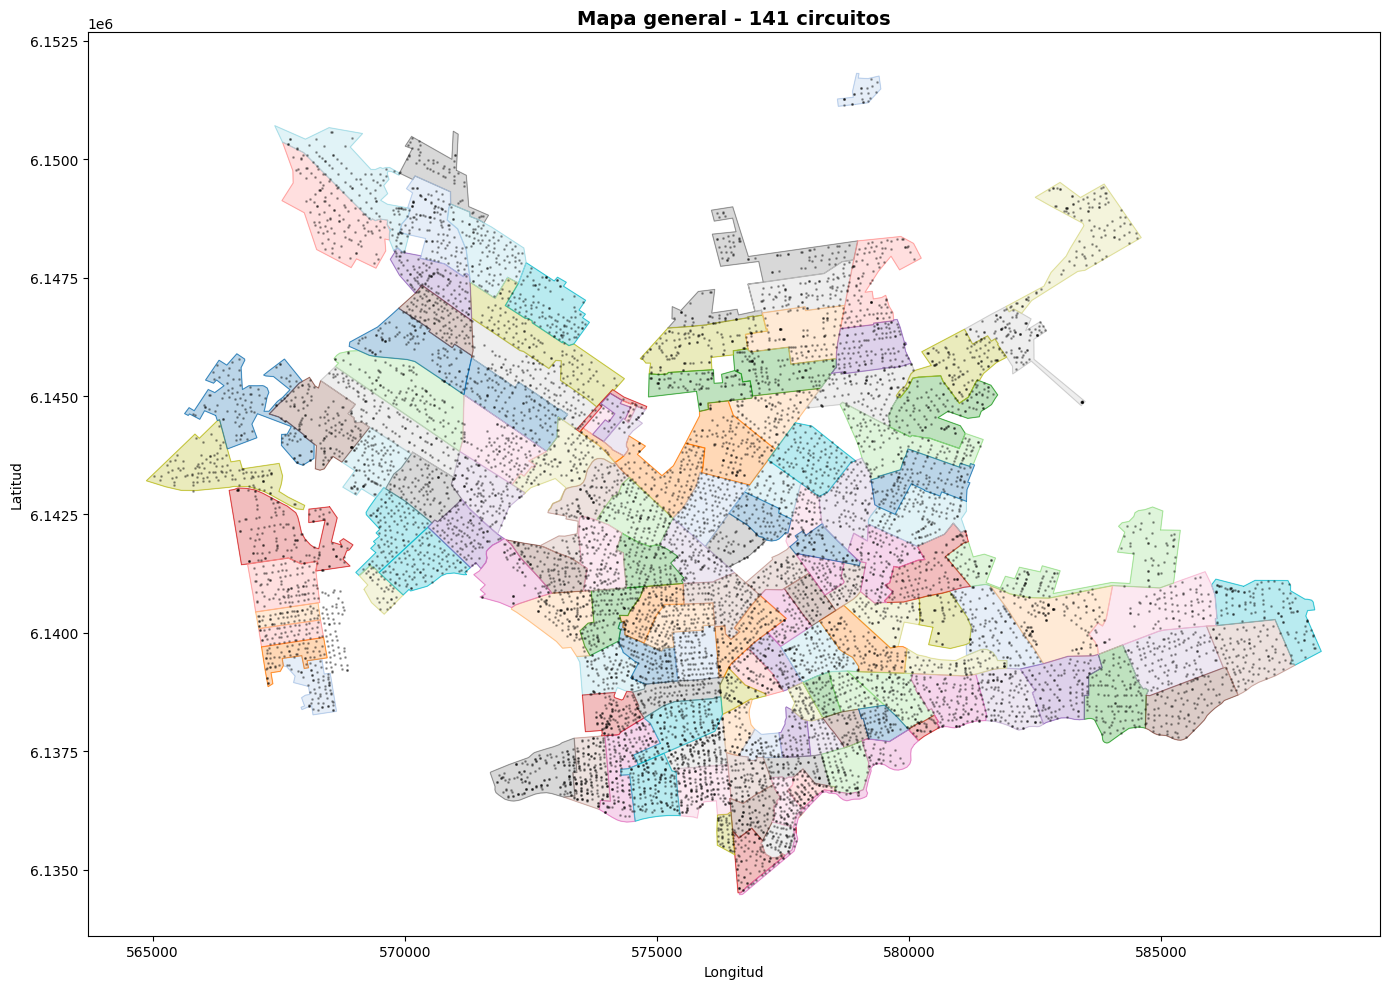

In [8]:
def mapa_general(mostrar_contenedores=False):
    fig, ax = plt.subplots(1, 1, figsize=(14, 10))
    colors = plt.cm.tab20.colors

    for i, (_, row) in enumerate(df_circuitos.iterrows()):
        polygons = parse_vertices(row.get('VERTICES', ''))
        color = colors[i % len(colors)]
        for poly in polygons:
            if len(poly) > 2:
                xs, ys = zip(*poly)
                ax.fill(xs, ys, alpha=0.3, color=color)
                ax.plot(xs + (xs[0],), ys + (ys[0],), color=color, linewidth=0.5)

    if mostrar_contenedores and 'X' in df_contenedores.columns:
        df_c = df_contenedores.dropna(subset=['X', 'Y'])
        ax.scatter(df_c['X'], df_c['Y'], s=1, c='black', alpha=0.3, zorder=5)

    ax.set_title(f'Mapa general - {len(df_circuitos)} circuitos', fontsize=14, fontweight='bold')
    ax.set_xlabel('Longitud'); ax.set_ylabel('Latitud')
    plt.tight_layout()
    plt.show()

mapa_general(mostrar_contenedores=True)

> Ejemplo de circuito individual. Se puede ver que algunos circuitos están compuestos por **dos polígonos separados**,  
> lo que implica rutas no contiguas geográficamente.

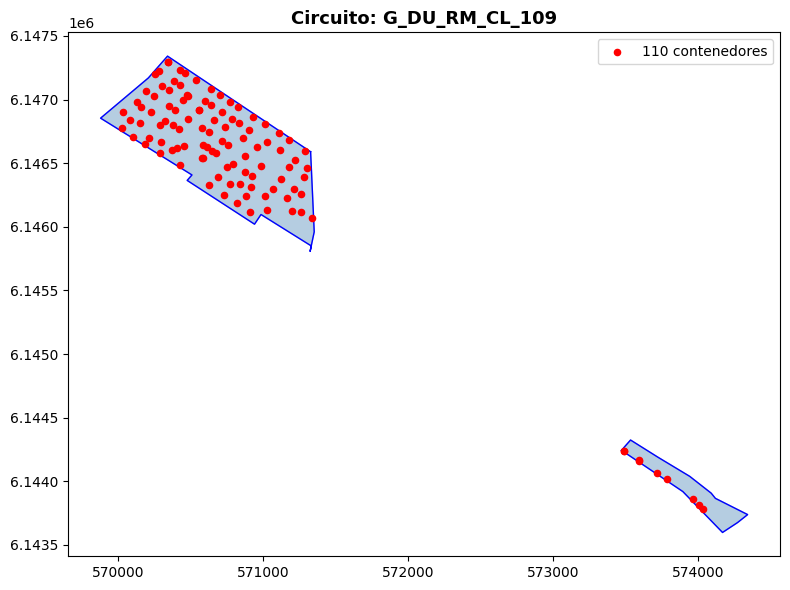

In [9]:
def visualizar_circuito(cod_circuito):
    rows = df_circuitos[df_circuitos['COD_CIRCUITO'] == cod_circuito]
    if rows.empty:
        print(f"Circuito {cod_circuito} no encontrado")
        return
    fig, ax = plt.subplots(figsize=(8, 6))
    # Iterar sobre TODAS las filas del circuito (algunos tienen 2 poligonos no contiguos)
    for _, row in rows.iterrows():
        polygons = parse_vertices(row.get('VERTICES', ''))
        for poly in polygons:
            if len(poly) > 2:
                xs, ys = zip(*poly)
                ax.fill(xs, ys, alpha=0.4, color='steelblue')
                ax.plot(xs + (xs[0],), ys + (ys[0],), 'b-', linewidth=1)
    df_cont_circ = df_contenedores[df_contenedores['COD_CIRCUITO'] == cod_circuito].dropna(subset=['X','Y'])
    if len(df_cont_circ) > 0:
        ax.scatter(df_cont_circ['X'], df_cont_circ['Y'], s=20, c='red', zorder=5, label=f'{len(df_cont_circ)} contenedores')
        ax.legend()
    ax.set_title(f'Circuito: {cod_circuito}', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

visualizar_circuito('G_DU_RM_CL_109')

### 2.2. Carga y Limpieza de Datos Temporales <a id='3'></a>

### 2.2. Carga y limpieza de datos temporales <a id='3'></a>

Se cargan los registros históricos de levantes (eventos de recolección) a nivel de contenedor individual con datos entre Enero de 2024 y Febrero de 2026.

Cada observación corresponde a un evento efectivo de recolección, identificado por el contenedor y la fecha en que se realizó el servicio.

Los datos se encuentran organizados en bloques cuatrimestrales:

- **Q1:** enero–abril  
- **Q2:** mayo–agosto  
- **Q3:** septiembre–diciembre  

Se cargan los archivos correspondientes al período enero 2024 – febrero 2026 (2024 Q1–Q3, 2025 Q1–Q3 y 2026 Q1), los cuales se concatenan en un único dataframe para su análisis.

En total, el dataset consolidado contiene aproximadamente **8.9 millones de registros**, lo que permite modelar patrones temporales a gran escala.

In [10]:
print("=" * 60)
print("CARGANDO DATOS TEMPORALES")
print("=" * 60)

archivos_levantes = {
    # 2024 - TRAIN
    '2024_Q1': 'levante_contenedores_01-04_2024.csv',
    '2024_Q2': 'levante_contenedores_05-08_2024.csv',
    '2024_Q3': 'levante_contenedores_09-12_2024.csv',
    # 2025 - TRAIN + VAL
    '2025_Q1': 'levante_contenedores_01-04_2025.csv',
    '2025_Q2': 'levante_contenedores_05-08_2025.csv',
    '2025_Q3': 'levante_contenedores_09-12_2025.csv',
    # 2026 - TEST
    '2026_Q1': 'levante_contenedores_01-04_2026.csv',
}

def cargar_levantes(filepath, periodo):
    """Carga un archivo de levantes con metadata del periodo"""
    df = pd.read_csv(filepath, sep=',', encoding='utf-8', low_memory=False)

    # Parsear fechas
    df['fecha_datos'] = pd.to_datetime(df['fecha_datos'])
    df['ult_levante'] = pd.to_datetime(df['ult_levante'])

    # Metadata temporal
    df['periodo'] = periodo
    df['año'] = df['fecha_datos'].dt.year
    df['mes'] = df['fecha_datos'].dt.month
    df['trimestre'] = df['fecha_datos'].dt.quarter

    print(f"  {periodo}: {len(df):,} registros | {df['fecha_datos'].min()} -> {df['fecha_datos'].max()}")
    return df

print("\nCargando archivos:")
dfs_levantes = []

for periodo, filename in archivos_levantes.items():
    filepath = DATA_RAW / filename
    if filepath.exists():
        df_temp = cargar_levantes(filepath, periodo)
        dfs_levantes.append(df_temp)
        print(f"  ✓ {periodo}: {len(df_temp):,} registros")
    else:
        print(f"  ✗ {periodo}: archivo no encontrado ({filename})")

if dfs_levantes:
    df_levantes = pd.concat(dfs_levantes, ignore_index=True)
    print(f"\nTotal registros: {len(df_levantes):,}")
    print(f"Rango temporal: {df_levantes['fecha_datos'].min()} → {df_levantes['fecha_datos'].max()}")
else:
    print("ERROR: No se encontraron archivos de levantes")

CARGANDO DATOS TEMPORALES

Cargando archivos:
  2024_Q1: 1,287,591 registros | 2024-01-01 06:00:00 -> 2024-04-29 06:00:00
  ✓ 2024_Q1: 1,287,591 registros
  2024_Q2: 1,324,464 registros | 2024-05-01 06:00:00 -> 2024-08-30 06:00:00
  ✓ 2024_Q2: 1,324,464 registros
  2024_Q3: 1,393,243 registros | 2024-09-01 06:00:00 -> 2024-12-30 06:00:00
  ✓ 2024_Q3: 1,393,243 registros
  2025_Q1: 1,414,831 registros | 2025-01-01 06:00:00 -> 2025-04-29 06:00:00
  ✓ 2025_Q1: 1,414,831 registros
  2025_Q2: 1,365,383 registros | 2025-05-01 06:00:00 -> 2025-08-30 06:00:00
  ✓ 2025_Q2: 1,365,383 registros
  2025_Q3: 1,450,344 registros | 2025-09-01 06:00:00 -> 2025-12-30 06:00:00
  ✓ 2025_Q3: 1,450,344 registros
  2026_Q1: 656,737 registros | 2026-01-01 06:00:00 -> 2026-02-23 06:00:00
  ✓ 2026_Q1: 656,737 registros

Total registros: 8,892,593
Rango temporal: 2024-01-01 06:00:00 → 2026-02-23 06:00:00


Se realiza una inspección estructural del dataframe consolidado, evaluando dimensiones, tipos de datos y presencia de valores faltantes.

El dataset contiene aproximadamente 8.9 millones de registros y 12 variables, incluyendo:

- Variables temporales (`fecha_datos`, `ult_levante`)
- Identificadores operativos (`circuito`, `cod_recorrido`, `posicion`)
- Información geográfica (`longitud`, `latitud`)
- Metadatos temporales derivados (`año`, `mes`, `trimestre`)

La columna `ult_levante` resulta fundamental para la construcción de la variable objetivo, ya que permite calcular el tiempo transcurrido desde la última recolección efectiva.

In [11]:
# ── EDA: df_levantes ──────────────────────────────────────────────────────────
print("=" * 60)
print("ANÁLISIS EXPLORATORIO - LEVANTES")
print("=" * 60)

display(df_levantes.head())
print("\nShape:", df_levantes.shape)
print("\nTipos de datos:")
print(df_levantes.dtypes)
print("\nValores nulos:")
print(df_levantes.isnull().sum()[df_levantes.isnull().sum() > 0])

ANÁLISIS EXPLORATORIO - LEVANTES


,fecha_datos,circuito,cod_recorrido,posicion,cod_motivo_inactiva,ult_levante,longitud,latitud,periodo,año,mes,trimestre
0,2024-01-01 06:00:00,A_101,A_DU_RM_CL_101,1,0,2023-12-30 07:00:00,-56.253808,-34.894386,2024_Q1,2024,1,1
1,2024-01-01 06:00:00,A_101,A_DU_RM_CL_101,2,0,2023-12-30 07:00:00,-56.255101,-34.894088,2024_Q1,2024,1,1
2,2024-01-01 06:00:00,A_101,A_DU_RM_CL_101,3,0,2023-12-30 07:00:00,-56.255324,-34.894037,2024_Q1,2024,1,1
3,2024-01-01 06:00:00,A_101,A_DU_RM_CL_101,4,0,2023-12-30 07:00:00,-56.254615,-34.893763,2024_Q1,2024,1,1
4,2024-01-01 06:00:00,A_101,A_DU_RM_CL_101,5,0,2023-12-30 07:00:00,-56.256204,-34.888647,2024_Q1,2024,1,1



Shape: (8892593, 12)

Tipos de datos:
fecha_datos            datetime64[ns]
circuito                       object
cod_recorrido                  object
posicion                        int64
cod_motivo_inactiva             int64
ult_levante            datetime64[ns]
longitud                      float64
latitud                       float64
periodo                        object
año                             int32
mes                             int32
trimestre                       int32
dtype: object

Valores nulos:
ult_levante    32383
longitud       86859
latitud        86859
dtype: int64


>La proporción de valores nulos es baja en términos relativos (<1% del total de registros).
>- Los nulos en `ult_levante` pueden corresponder a contenedores recientemente incorporados o registros iniciales sin histórico previo.
>- Los nulos en coordenadas geográficas podrían deberse a inconsistencias administrativas o registros incompletos.
>Dado su bajo peso relativo, estos casos no comprometen la representatividad global del dataset.

*Distribución de días de acumulación (antes de limpieza)*

Se analiza la distribución de `dias_acumulacion` previa a cualquier filtrado con el objetivo de comprender su comportamiento global.

Los percentiles muestran una fuerte concentración en valores bajos:

- Mediana (P50): 1.65 días  
- P75: 2.67 días  
- P90: 3.97 días  
- P95: 4.98 días  

Esto indica que el régimen operativo habitual de recolección se encuentra mayormente dentro de los primeros 5 días.

Sin embargo, a partir del percentil 99 (30.87 días) se observa una ruptura clara en la distribución, con una cola larga que alcanza valores extremadamente altos (P99.9 ≈ 264 días).

Estos eventos representan una fracción reducida del total, pero introducen fuerte asimetría y varianza en la variable objetivo.

Dado que el modelo busca capturar el comportamiento regular del sistema y no episodios excepcionales, resulta necesario evaluar estrategias de tratamiento de estos valores extremos.

VISUALIZACIÓN DE OUTLIERS - DÍAS DE ACUMULACIÓN


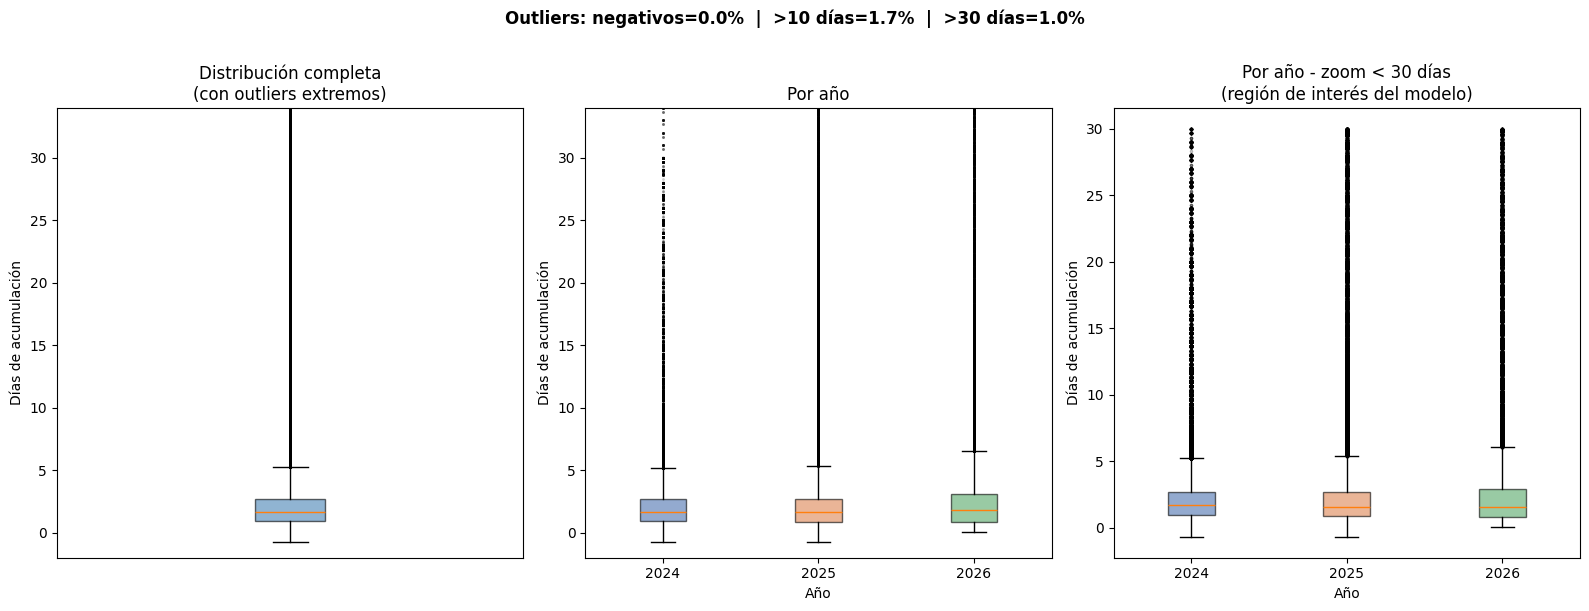


Percentiles de dias_acumulacion (pre-limpieza):
  P50   : 1.65 días
  P75   : 2.67 días
  P90   : 3.97 días
  P95   : 4.98 días
  P99   : 30.87 días
  P99.9 : 263.74 días


In [12]:
# ── Boxplots de outliers en dias_acumulacion ──────────────────────────────────
print("=" * 60)
print("VISUALIZACIÓN DE OUTLIERS - DÍAS DE ACUMULACIÓN")
print("=" * 60)

# Calcular dias_acumulacion temporalmente para visualizar
# (antes de la limpieza formal)
dias_temp = (
    (df_levantes['fecha_datos'] - df_levantes['ult_levante'])
    .dt.total_seconds() / 86400
)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# ── 1. Boxplot general (sin cap) ─────────────────────────────
axes[0].boxplot(dias_temp.dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                flierprops=dict(marker='.', markersize=2, alpha=0.3, color='crimson'))
axes[0].set_title('Distribución completa\n(con outliers extremos)')
axes[0].set_ylabel('Días de acumulación')
axes[0].set_xticks([])

# ── 2. Boxplot por año ────────────────────────────────────────
datos_por_año = [dias_temp[df_levantes['año'] == a].dropna().values
                 for a in sorted(df_levantes['año'].unique())]
años = sorted(df_levantes['año'].unique())

bp = axes[1].boxplot(datos_por_año, vert=True, patch_artist=True,
                     labels=años,
                     flierprops=dict(marker='.', markersize=2, alpha=0.2, color='crimson'))
colors = ['#4C72B0', '#DD8452', '#55A868']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[1].set_title('Por año')
axes[1].set_ylabel('Días de acumulación')
axes[1].set_xlabel('Año')

# ── 3. Boxplot por año - zoom sin extremos (< 30 días) ────────
datos_zoom = [dias_temp[(df_levantes['año'] == a) & (dias_temp < 30)].dropna().values
              for a in años]

bp2 = axes[2].boxplot(datos_zoom, vert=True, patch_artist=True,
                      labels=años,
                      flierprops=dict(marker='.', markersize=3, alpha=0.3, color='crimson'))
for patch, color in zip(bp2['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[2].set_title('Por año - zoom < 30 días\n(región de interés del modelo)')
axes[2].set_ylabel('Días de acumulación')
axes[2].set_xlabel('Año')

# Estadísticas clave como texto
total = len(dias_temp.dropna())
pct_neg    = (dias_temp < 0).sum() / total * 100
pct_over10 = (dias_temp > 10).sum() / total * 100
pct_over30 = (dias_temp > 30).sum() / total * 100

fig.suptitle(
    f'Outliers: negativos={pct_neg:.1f}%  |  >10 días={pct_over10:.1f}%  |  >30 días={pct_over30:.1f}%',
    fontsize=12, fontweight='bold', y=1.01
)
p99 = float(np.percentile(dias_temp.dropna(), 99))
axes[0].set_ylim(bottom=-2, top=p99 * 1.1)
axes[1].set_ylim(bottom=-2, top=p99 * 1.1)
plt.tight_layout()
plt.show()

print(f"\nPercentiles de dias_acumulacion (pre-limpieza):")
for p in [50, 75, 90, 95, 99, 99.9]:
    print(f"  P{p:<5}: {dias_temp.quantile(p/100):.2f} días")

*Verificaciones estructurales y consistencia operativa*

Se realizan controles adicionales para validar la coherencia entre las distintas fuentes de información:

1. **Consistencia de circuitos:**  
   Se verifica que los códigos de recorrido presentes en los registros de levantes coincidan con los polígonos disponibles en `df_circuitos`.

2. **Circuitos sin geometría asociada:**  
   Se identifican 15 circuitos operativos que no poseen correspondencia geométrica en el dataset de polígonos, afectando aproximadamente el 2.4% de los registros.

3. **Acumulaciones negativas:**  
   Se detecta un 0.03% de registros con diferencia temporal negativa entre `fecha_datos` y `ult_levante`.

Este fenómeno se explica por la lógica operativa del sistema: el campo `ult_levante` refleja el último levante registrado durante el día completo, mientras que el snapshot de datos se toma a las 06:00 horas, lo que puede generar desfasajes temporales menores.

In [13]:
# ── Hallazgos clave ───────────────────────────────────────────────────────────
print("=" * 60)
print("ANÁLISIS DE HALLAZGOS CLAVE")
print("=" * 60)

# Circuitos
print("\nCircuitos únicos en df_levantes (cod_recorrido):")
print(f"  {df_levantes['cod_recorrido'].nunique()} circuitos")

# Circuitos sin geometría
circuitos_sin_geometria = set(df_levantes['cod_recorrido'].unique()) - set(df_circuitos['COD_CIRCUITO'].unique())
print(f"\nCircuitos en levantes sin geometría en df_circuitos: {len(circuitos_sin_geometria)}")

# Distribución temporal de circuitos sin geometría
if circuitos_sin_geometria:
    mask_sg = df_levantes['cod_recorrido'].isin(circuitos_sin_geometria)
    print(f"  Registros afectados: {mask_sg.sum():,} ({mask_sg.mean()*100:.1f}%)")

# Acumulación negativa
negatv = (df_levantes['fecha_datos'] - df_levantes['ult_levante']).dt.total_seconds() / 86400 < 0
print(f"\nRegistros con días_acumulación negativa (pre-corrección): {negatv.sum():,} ({negatv.mean()*100:.2f}%)")

ANÁLISIS DE HALLAZGOS CLAVE

Circuitos únicos en df_levantes (cod_recorrido):
  149 circuitos

Circuitos en levantes sin geometría en df_circuitos: 15
  Registros afectados: 213,742 (2.4%)

Registros con días_acumulación negativa (pre-corrección): 2,939 (0.03%)


## 3. Feature Engineering y EDA Avanzado <a id='4'></a>



> Creamos la variable `dias_acumulacion` se calcula como la diferencia en días entre la fecha del registro (`fecha_datos`) y el último levante registrado para ese contenedor (`ult_levante`).
> Esta variable representa el tiempo transcurrido desde la última recolección efectiva, y constituye el target del modelo predictivo.
>Se aplica un recorte inferior en cero para evitar inconsistencias derivadas de posibles errores.

>Correcciones aplicadas:
- **Acumulación negativa**: se aplica `.clip(lower=0)` porque vimos que los valores negativos son resultado del sistema de registro.
- **cod_motivo_inactiva**: se conservan todos los registros pero se filtra al modelar (solo `cod=0`).  
- **Coordenadas faltantes**: no se imputan ya que corresponden a contenedores recién incorporados, no son errores.


In [14]:
# ── 1. Crear variable objetivo: dias_acumulacion ──────────────────────────────
df_levantes['dias_acumulacion'] = (
    (df_levantes['fecha_datos'] - df_levantes['ult_levante'])
    .dt.total_seconds() / 86400
).clip(lower=0)

print("✓ dias_acumulacion creada")
print(df_levantes['dias_acumulacion'].describe().round(2))

✓ dias_acumulacion creada
count    8860210.00
mean           3.36
std           16.65
min            0.00
25%            0.96
50%            1.65
75%            2.67
max          609.67
Name: dias_acumulacion, dtype: float64


> Un amplio porcentage de las observaciones corresponden a contenedores activos (`cod=0`).  
> Los códigos 1, 2 y 4 representan distintos motivos de inactividad que se conservan para no perder continuidad temporal.

In [15]:
# ── 2. Análisis de cod_motivo_inactiva ────────────────────────────────────────
print("DISTRIBUCIÓN DE COD_MOTIVO_INACTIVA")
vc = df_levantes['cod_motivo_inactiva'].value_counts()
print(vc)
print("\n→ DECISIÓN: mantener todos los registros, filtrar al modelar (solo cod=0)")

DISTRIBUCIÓN DE COD_MOTIVO_INACTIVA
cod_motivo_inactiva
0    8568832
1     310551
2      10623
4       2587
Name: count, dtype: int64

→ DECISIÓN: mantener todos los registros, filtrar al modelar (solo cod=0)


*Construcción del identificador único de contenedor*

El dataset no contiene un identificador explícito único por contenedor físico.

Por lo tanto, se construye un ID compuesto combinando:

- `cod_recorrido` (circuito operativo)
- `posicion` (orden dentro del recorrido)

Esta combinación permite identificar de manera consistente cada contenedor individual a lo largo del tiempo y modelar su comportamiento histórico.

In [16]:
# ── 3. Contenedor ID unificado ────────────────────────────────────────────────
df_levantes['contenedor_id'] = df_levantes['cod_recorrido'] + '_pos_' + df_levantes['posicion'].astype(str)
print(f"✓ Contenedores únicos creados: {df_levantes['contenedor_id'].nunique():,}")

✓ Contenedores únicos creados: 13,518


*Clasificación de contenedores según comportamiento histórico*

Se analiza la proporción de registros con acumulaciones extremas (>30 días) para cada contenedor individual.

En función de este criterio, se definen tres categorías:

- **A_normal:** comportamiento estable, con baja proporción de valores extremos.
- **B_intermitente:** presencia ocasional de eventos extremos.
- **C_alta_irregularidad:** más del 30% de los registros presentan acumulaciones superiores a 30 días.

Los contenedores de la última categoría se excluyen del modelado, dado que su comportamiento no refleja el régimen operativo habitual y podría introducir sesgos significativos en el entrenamiento.

In [17]:
# ── 4. Clasificación de contenedores por comportamiento ───────────────────────
print("=" * 60)
print("CLASIFICACIÓN DE CONTENEDORES POR COMPORTAMIENTO")
print("=" * 60)

df_activos = df_levantes[df_levantes['cod_motivo_inactiva'] == 0].copy()

contenedores_stats = df_activos.groupby('contenedor_id').agg(
    n_obs=('dias_acumulacion', 'count'),
    media=('dias_acumulacion', 'mean'),
    std=('dias_acumulacion', 'std'),
    extremos=('dias_acumulacion', lambda x: (x > 30).sum())
).reset_index()

contenedores_stats['pct_extremos'] = contenedores_stats['extremos'] / contenedores_stats['n_obs']

def clasificar(row):
    if row['pct_extremos'] > 0.3: return 'C_problematico'
    if row['pct_extremos'] > 0.05: return 'B_intermitente'
    return 'A_normal'

contenedores_stats['tipo'] = contenedores_stats.apply(clasificar, axis=1)

print(contenedores_stats['tipo'].value_counts())
print(f"\nTotal contenedores clasificados: {len(contenedores_stats):,}")

df_levantes = df_levantes.merge(
    contenedores_stats[['contenedor_id', 'tipo']],
    on='contenedor_id', how='left'
)
print("✓ Clasificación mergeada a df_levantes")

CLASIFICACIÓN DE CONTENEDORES POR COMPORTAMIENTO
tipo
A_normal          13062
B_intermitente      237
C_problematico      183
Name: count, dtype: int64

Total contenedores clasificados: 13,482
✓ Clasificación mergeada a df_levantes


*Ingeniería de variables temporales*

Se incorporan variables derivadas del calendario a partir de `fecha_datos`, con el objetivo de capturar posibles patrones sistemáticos en la frecuencia de recolección.

Las variables generadas incluyen:

- `dia_semana`: permite modelar diferencias operativas entre días hábiles y fines de semana.
- `dia_mes`: captura posibles regularidades dentro del ciclo mensual.
- `mes`: permite incorporar efectos estacionales.
- `trimestre`: aproxima variaciones de mayor escala temporal.

Estas variables buscan complementar la dinámica histórica del contenedor con información estructural del calendario.

In [18]:
# ── 5. Features temporales ────────────────────────────────────────────────────
df_levantes['dia_semana'] = df_levantes['fecha_datos'].dt.dayofweek
df_levantes['dia_mes']    = df_levantes['fecha_datos'].dt.day
df_levantes['mes']        = df_levantes['fecha_datos'].dt.month
df_levantes['trimestre']  = df_levantes['fecha_datos'].dt.quarter
print("✓ Features temporales creadas")

✓ Features temporales creadas


*Distribución de la acumulación según el calendario*

Se analiza la distribución de `dias_acumulacion` para contenedores activos y valores inferiores a 30 días, con el objetivo de excluir únicamente los extremos más severos y observar la dinámica general del sistema.

Los resultados muestran:

- Alta concentración de la distribución en valores bajos.
- Variaciones moderadas del promedio según día de la semana.
- Diferencias leves entre meses.

En términos agregados, el efecto calendario parece relativamente estable y de baja magnitud comparado con la variabilidad total del sistema.

Esto sugiere que la dinámica principal de acumulación podría estar más asociada al comportamiento histórico específico de cada contenedor que a patrones globales de calendario.

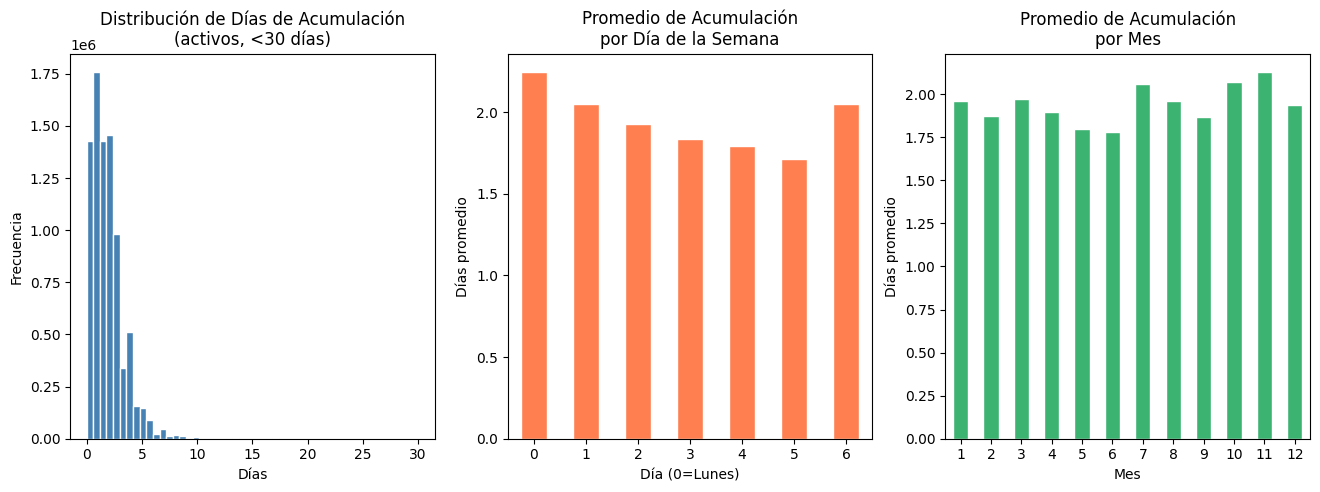

In [19]:
# ── 6. EDA visual ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Distribución de días de acumulación
df_activos_plot = df_levantes[
    (df_levantes['cod_motivo_inactiva'] == 0) &
    (df_levantes['dias_acumulacion'] < 30)
]
axes[0].hist(df_activos_plot['dias_acumulacion'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de Días de Acumulación\n(activos, <30 días)')
axes[0].set_xlabel('Días'); axes[0].set_ylabel('Frecuencia')

# Promedio de acumulación por día de la semana
df_activos_plot.groupby('dia_semana')['dias_acumulacion'].mean().plot(
    kind='bar', ax=axes[1], color='coral', edgecolor='white'
)
axes[1].set_title('Promedio de Acumulación\npor Día de la Semana')
axes[1].set_xlabel('Día (0=Lunes)'); axes[1].set_ylabel('Días promedio')
axes[1].tick_params(axis='x', rotation=0)

# Promedio por mes
df_activos_plot.groupby('mes')['dias_acumulacion'].mean().plot(
    kind='bar', ax=axes[2], color='mediumseagreen', edgecolor='white'
)
axes[2].set_title('Promedio de Acumulación\npor Mes')
axes[2].set_xlabel('Mes'); axes[2].set_ylabel('Días promedio')
axes[2].tick_params(axis='x', rotation=0)

*Análisis de correlación con la variable objetivo*

Se evalúa la correlación de Pearson entre las variables de calendario y `dias_acumulacion`, restringiendo el análisis al régimen habitual del sistema (<10 días) y a contenedores de comportamiento normal.

Las correlaciones observadas para las variables de calendario son bajas en términos absolutos, lo que indica capacidad predictiva limitada cuando se consideran de manera aislada.

En contraste, variables basadas en memoria temporal del propio contenedor —como `lag_1` y la media móvil de 7 días— presentan correlaciones sustancialmente mayores.

Este resultado respalda la hipótesis de que la dinámica de acumulación posee una componente autorregresiva dominante.

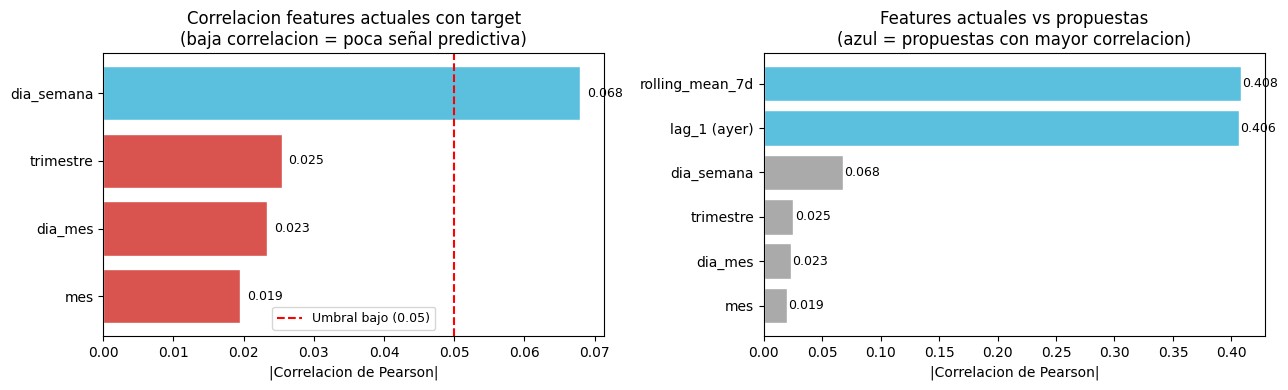

lag_1 correlacion: 0.406
rolling_mean_7d correlacion: 0.408
-> Los lags tienen 11.9x mas correlacion que las features actuales en promedio


In [20]:
# ── Correlacion de features con target (justifica lags) ─────────────────────
df_corr = df_levantes[
    (df_levantes['cod_motivo_inactiva'] == 0) &
    (df_levantes['tipo'] == 'A_normal') &
    (df_levantes['dias_acumulacion'] < 10)
][['dias_acumulacion', 'dia_semana', 'dia_mes', 'mes', 'trimestre']].copy()

# Correlacion de Pearson
corr = df_corr.corr()['dias_acumulacion'].drop('dias_acumulacion').abs().sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Correlaciones actuales
colors_bar = ['#d9534f' if v < 0.05 else '#5bc0de' for v in corr.values]
axes[0].barh(corr.index, corr.values, color=colors_bar, edgecolor='white')
axes[0].axvline(0.05, color='red', linestyle='--', linewidth=1.5, label='Umbral bajo (0.05)')
axes[0].set_title('Correlacion features actuales con target\n(baja correlacion = poca señal predictiva)')
axes[0].set_xlabel('|Correlacion de Pearson|')
axes[0].legend(fontsize=9)
for i, (idx, val) in enumerate(corr.items()):
    axes[0].text(val + 0.001, i, f'{val:.3f}', va='center', fontsize=9)

# Features propuestas vs actuales
features_actuales = {'dia_semana': corr.get('dia_semana', 0), 'mes': corr.get('mes', 0),
                     'trimestre': corr.get('trimestre', 0), 'dia_mes': corr.get('dia_mes', 0)}

# Calcular correlacion de lag_1 como referencia
df_corr_lag = df_levantes[
    (df_levantes['cod_motivo_inactiva'] == 0) &
    (df_levantes['tipo'] == 'A_normal') &
    (df_levantes['dias_acumulacion'] < 10)
][['contenedor_id', 'fecha_datos', 'dias_acumulacion']].copy()
df_corr_lag = df_corr_lag.sort_values(['contenedor_id', 'fecha_datos'])
df_corr_lag['lag_1'] = df_corr_lag.groupby('contenedor_id')['dias_acumulacion'].shift(1)
df_corr_lag['rolling_mean_7'] = df_corr_lag.groupby('contenedor_id')['dias_acumulacion'].transform(
    lambda x: x.shift(1).rolling(7, min_periods=2).mean())
df_corr_lag = df_corr_lag.dropna()

lag1_corr = df_corr_lag['lag_1'].corr(df_corr_lag['dias_acumulacion'])
roll_corr = df_corr_lag['rolling_mean_7'].corr(df_corr_lag['dias_acumulacion'])

features_propuestas = {
    'lag_1 (ayer)': abs(lag1_corr),
    'rolling_mean_7d': abs(roll_corr),
    **features_actuales
}
fp_sorted = dict(sorted(features_propuestas.items(), key=lambda x: x[1]))
colors_prop = ['#5bc0de' if k.startswith('lag') or k.startswith('roll') else '#aaaaaa'
               for k in fp_sorted.keys()]

axes[1].barh(list(fp_sorted.keys()), list(fp_sorted.values()), color=colors_prop, edgecolor='white')
axes[1].set_title('Features actuales vs propuestas\n(azul = propuestas con mayor correlacion)')
axes[1].set_xlabel('|Correlacion de Pearson|')
for i, (k, v) in enumerate(fp_sorted.items()):
    axes[1].text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f"lag_1 correlacion: {lag1_corr:.3f}")
print(f"rolling_mean_7d correlacion: {roll_corr:.3f}")
print(f"-> Los lags tienen {abs(lag1_corr)/corr.mean():.1f}x mas correlacion que las features actuales en promedio")

*Análisis de Varianza*

Se comparó la variabilidad de dias_acumulacion dentro de cada contenedor y entre contenedores, considerando solo activos normales y valores <20 días.

Encontramos que la mayor parte de la variabilidad ocurre dentro de cada contenedor a lo largo del tiempo. Las diferencias estructurales entre contenedores existen, pero son mucho menores que la variación temporal.

La señal principal es temporal, aunque incluir la identidad del contenedor puede aportar información adicional.

In [21]:
# ── 7. Análisis de varianza ───────────────────────────────────────────────────
print("=" * 60)
print("ANÁLISIS DE VARIANZA (solo activos normales)")
print("=" * 60)

df_anova = df_levantes[
    (df_levantes['cod_motivo_inactiva'] == 0) &
    (df_levantes['tipo'] == 'A_normal') &
    (df_levantes['dias_acumulacion'] < 20)
].copy()

# Variabilidad intra vs inter contenedor
intra_var = df_anova.groupby('contenedor_id')['dias_acumulacion'].var().mean()
inter_var = df_anova.groupby('contenedor_id')['dias_acumulacion'].mean().var()

print(f"\nVarianza INTRA-contenedor (promedio): {intra_var:.3f}")
print(f"Varianza INTER-contenedor (de medias): {inter_var:.3f}")
print(f"\nRatio inter/intra: {inter_var/intra_var:.2f}")
print("→ Ratio alto indica diferencias sistemáticas entre contenedores (justifica el embedding)")

ANÁLISIS DE VARIANZA (solo activos normales)

Varianza INTRA-contenedor (promedio): 2.151
Varianza INTER-contenedor (de medias): 0.464

Ratio inter/intra: 0.22
→ Ratio alto indica diferencias sistemáticas entre contenedores (justifica el embedding)


## 4. Preparación de Datos para Modelado (Pipeline Limpio) <a id='5'></a>
*Aplicación del pipeline y split temporal*

Se aplicaron los filtros definidos:

- Solo contenedores `A_normal` y `B_intermitente`
- Solo registros activos
- `dias_acumulacion < 10`

Luego del filtrado:

- **8,373,328 registros**
- **13,299 contenedores únicos**

No se realizó submuestreo: se utilizó el dataset completo. Esto fue posible gracias a usar la GPU P100 disponible en Kaggle.

---

*Split temporal*

Se realizó un split estrictamente temporal (80/10/10) usando cuantiles de fecha.

**Resultado final:**

- **Train:** 2024-01-01 → 2025-09-25 (6,707,186 registros)  
- **Val:** 2025-09-26 → 2025-12-09 (830,482 registros)  
- **Test:** 2025-12-10 → 2026-02-23 (835,660 registros)

El modelo se entrena únicamente con datos del pasado y se evalúa en períodos posteriores, simulando el uso real en producción.

In [22]:
print("=" * 60)
print("PIPELINE LIMPIO: FILTRADO + SECUENCIAS + SPLIT TEMPORAL")
print("=" * 60)

# ── Configuración ────────────────────────────────────────────
feature_cols = ['dias_acumulacion', 'dia_semana', 'mes', 'trimestre']
SEQUENCE_LENGTH = 7
UMBRAL_MAX = 10
N_CONTENEDORES_MUESTRA = None  # None = todos los contenedores (Kaggle 30GB RAM)
# N_CONTENEDORES_MUESTRA = 3000  # descomentar si se queda sin RAM

n_muestra_str = str(N_CONTENEDORES_MUESTRA) if N_CONTENEDORES_MUESTRA else 'TODOS'
print(f"Features       : {feature_cols}")
print(f"Seq length     : {SEQUENCE_LENGTH}")
print(f"Umbral máximo  : {UMBRAL_MAX} días")
print(f"Contenedores   : {n_muestra_str}")

# ── Filtrado ─────────────────────────────────────────────────
df = df_levantes[
    (df_levantes['cod_motivo_inactiva'] == 0) &
    (df_levantes['tipo'].isin(['A_normal', 'B_intermitente'])) &
    (df_levantes['dias_acumulacion'] < UMBRAL_MAX)
].copy()

print(f"\nRegistros tras filtrado: {len(df):,}")
print(f"Contenedores únicos    : {df['contenedor_id'].nunique():,}")

# ── Selección de contenedores ─────────────────────────────────
np.random.seed(42)
contenedores_A = df[df['tipo'] == 'A_normal']['contenedor_id'].unique()
contenedores_B = df[df['tipo'] == 'B_intermitente']['contenedor_id'].unique()

if N_CONTENEDORES_MUESTRA is None:
    df_modelo_small = df.copy()
    print(f"Dataset completo: {df['contenedor_id'].nunique():,} contenedores")
else:
    n_A = int(N_CONTENEDORES_MUESTRA * len(contenedores_A) / (len(contenedores_A) + len(contenedores_B)))
    n_B = N_CONTENEDORES_MUESTRA - n_A
    muestra_A = np.random.choice(contenedores_A, min(n_A, len(contenedores_A)), replace=False)
    muestra_B = np.random.choice(contenedores_B, min(n_B, len(contenedores_B)), replace=False)
    contenedores_sample = np.concatenate([muestra_A, muestra_B])
    df_modelo_small = df[df['contenedor_id'].isin(contenedores_sample)].copy()
    print(f"Muestra: {len(contenedores_sample):,} contenedores ({n_A} tipo A + {n_B} tipo B)")

df_modelo_small = df_modelo_small.sort_values(['contenedor_id', 'fecha_datos'])
print(f"Registros en dataset   : {len(df_modelo_small):,}")

# Liberar df completo
del df
gc.collect()

# ── Recodificar contenedores ─────────────────────────────────
le_contenedor = LabelEncoder()
df_modelo_small['contenedor_idx'] = le_contenedor.fit_transform(df_modelo_small['contenedor_id'])
n_contenedores = df_modelo_small['contenedor_idx'].nunique()

# ── Split temporal ────────────────────────────────────────────
print("\n── Split temporal ──")
fecha_train_fin = df_modelo_small['fecha_datos'].quantile(0.8)
fecha_val_fin   = df_modelo_small['fecha_datos'].quantile(0.9)

train_df = df_modelo_small[df_modelo_small['fecha_datos'] <= fecha_train_fin].copy()
val_df   = df_modelo_small[
    (df_modelo_small['fecha_datos'] > fecha_train_fin) &
    (df_modelo_small['fecha_datos'] <= fecha_val_fin)
].copy()
test_df  = df_modelo_small[df_modelo_small['fecha_datos'] > fecha_val_fin].copy()

del df_modelo_small
gc.collect()

print(f"Train : {train_df['fecha_datos'].min().date()} → {train_df['fecha_datos'].max().date()} ({len(train_df):,} registros)")
print(f"Val   : {val_df['fecha_datos'].min().date()} → {val_df['fecha_datos'].max().date()} ({len(val_df):,} registros)")
print(f"Test  : {test_df['fecha_datos'].min().date()} → {test_df['fecha_datos'].max().date()} ({len(test_df):,} registros)")


PIPELINE LIMPIO: FILTRADO + SECUENCIAS + SPLIT TEMPORAL
Features       : ['dias_acumulacion', 'dia_semana', 'mes', 'trimestre']
Seq length     : 7
Umbral máximo  : 10 días
Contenedores   : TODOS

Registros tras filtrado: 8,373,328
Contenedores únicos    : 13,299
Dataset completo: 13,299 contenedores
Registros en dataset   : 8,373,328

── Split temporal ──
Train : 2024-01-01 → 2025-09-25 (6,707,186 registros)
Val   : 2025-09-26 → 2025-12-09 (830,482 registros)
Test  : 2025-12-10 → 2026-02-23 (835,660 registros)


> Generamos las secuencias de longitud 7: para cada contenedor, tomamos 7 días consecutivos como entrada y el día siguiente como target.  
> Resultado con dataset completo: del orden de **millones de secuencias** — el número exacto se verá al ejecutar.

*Generación de secuencias*

Se construyen secuencias de longitud 7 para cada contenedor.

Para cada contenedor:
- Se toman 7 días consecutivos como variables de entrada.
- El día siguiente se utiliza como variable objetivo (`dias_acumulacion`).

La decisión de usar una ventana de 7 días fue para capturar patrones semanales con suficiente contexto reciente sin aumentar excesivamente la complejidad del modelo.

Dado que se utiliza el dataset completo (13,299 contenedores y cerca de 9 millones de registros), el resultado es del orden de millones de secuencias para entrenamiento, validación y test.


In [23]:
# ── Generador de secuencias ───────────────────────────────────────────────────
def generar_secuencias(df_subset):
    X_list, y_list, contenedor_idx_list = [], [], []
    for cont_id, df_cont in df_subset.groupby('contenedor_id'):
        if len(df_cont) < SEQUENCE_LENGTH + 1:
            continue
        df_cont = df_cont.sort_values('fecha_datos')
        X_features = df_cont[feature_cols].values
        cont_idx = df_cont['contenedor_idx'].iloc[0]
        for j in range(len(df_cont) - SEQUENCE_LENGTH):
            X_list.append(X_features[j:j+SEQUENCE_LENGTH])
            y_list.append(X_features[j+SEQUENCE_LENGTH, 0])  # dias_acumulacion
            contenedor_idx_list.append(cont_idx)
    return np.array(X_list), np.array(y_list), np.array(contenedor_idx_list)

print("Generando secuencias...")
X_train, y_train, cont_train = generar_secuencias(train_df)
X_val,   y_val,   cont_val   = generar_secuencias(val_df)
X_test,  y_test,  cont_test  = generar_secuencias(test_df)

print(f"Train : {len(X_train):,} secuencias  shape={X_train.shape}")
print(f"Val   : {len(X_val):,} secuencias  shape={X_val.shape}")
print(f"Test  : {len(X_test):,} secuencias  shape={X_test.shape}")

Generando secuencias...
Train : 6,614,952 secuencias  shape=(6614952, 7, 4)
Val   : 749,910 secuencias  shape=(749910, 7, 4)
Test  : 755,014 secuencias  shape=(755014, 7, 4)


*Validación del split temporal*

Se verifica visualmente que el split sea estrictamente temporal y no exista superposición entre conjuntos.

En el gráfico de registros por fecha se observa:

- Separación clara entre train, validation y test.
- Un evento puntual dentro del período de train donde la cantidad de registros cae abruptamente. Este pico negativo corresponde a un día con datos faltantes y no a un problema del split. Intentamos validar fechas de paros u otro acontecimiento y no encontramos.

Fuera de ese evento aislado, el volumen de registros se mantiene estable a lo largo del tiempo.

En la distribución del target (`dias_acumulacion`):

- Las distribuciones de train, validation y test son muy similares.
- Las medias entre splits son prácticamente iguales.
- No se observan cambios estructurales en la forma de la distribución..
- No se observa evidencia de data leakage.

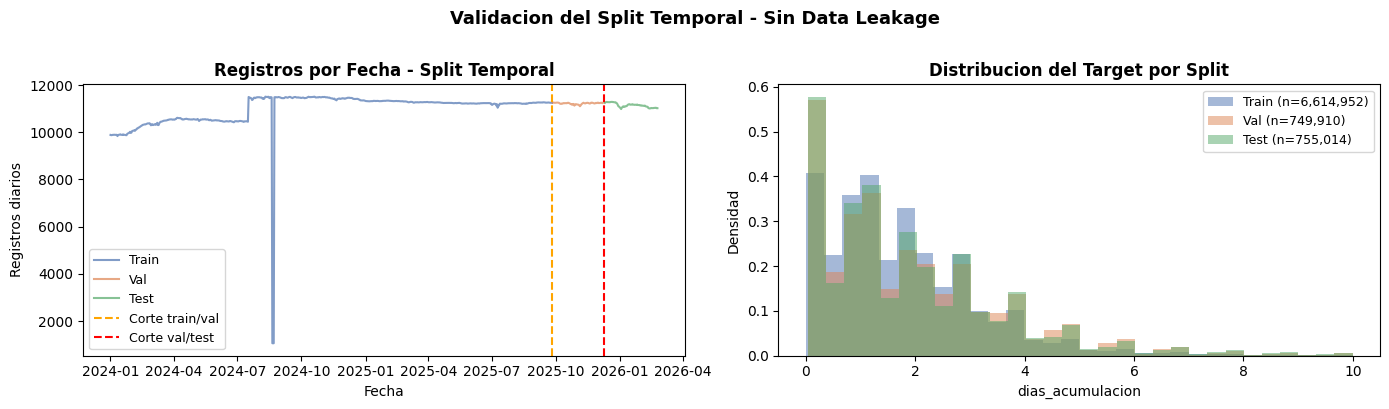

Distribucion similar entre splits -> no hay data leakage
Train media: 1.85 | Val media: 1.98 | Test media: 1.94


In [24]:
# ── Visualización del split temporal ─────────────────────────────────────────
# Se ejecuta ANTES de liberar train_df/val_df/test_df de memoria
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Registros por fecha en cada split
for split, color, df_sp in [('Train', '#4C72B0', train_df), ('Val', '#DD8452', val_df), ('Test', '#55A868', test_df)]:
    counts = df_sp.groupby('fecha_datos').size()
    axes[0].plot(counts.index, counts.values, alpha=0.7, label=split, color=color)

axes[0].axvline(fecha_train_fin, color='orange', linestyle='--', linewidth=1.5, label='Corte train/val')
axes[0].axvline(fecha_val_fin,   color='red',    linestyle='--', linewidth=1.5, label='Corte val/test')
axes[0].set_title('Registros por Fecha - Split Temporal', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Fecha'); axes[0].set_ylabel('Registros diarios')
axes[0].legend(fontsize=9)

# Distribucion del target en cada split
for ax, (split, y, color) in zip(
    [axes[1]],
    [('Comparacion splits', np.concatenate([y_train[:100000], y_val[:20000], y_test[:20000]]), 'gray')]
):
    pass

# Histogramas superpuestos del target
for split, y, color in [('Train', y_train, '#4C72B0'), ('Val', y_val, '#DD8452'), ('Test', y_test, '#55A868')]:
    axes[1].hist(y, bins=30, alpha=0.5, color=color, label=f'{split} (n={len(y):,})', density=True)

axes[1].set_title('Distribucion del Target por Split', fontsize=12, fontweight='bold')
axes[1].set_xlabel('dias_acumulacion'); axes[1].set_ylabel('Densidad')
axes[1].legend(fontsize=9)

plt.suptitle('Validacion del Split Temporal - Sin Data Leakage', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("Distribucion similar entre splits -> no hay data leakage")
print(f"Train media: {y_train.mean():.2f} | Val media: {y_val.mean():.2f} | Test media: {y_test.mean():.2f}")

In [25]:
# Liberar train_df, val_df, test_df - ya se convirtieron a arrays numpy
del train_df, val_df, test_df
gc.collect()
print("Memoria liberada")


Memoria liberada


*Distribución del target por split*

Se comparó la distribución de `dias_acumulacion` en train, validation y test.

Las tres distribuciones presentan forma similar y medias cercanas entre sí.  
Validation y test muestran una leve mayor dispersión respecto a train, pero no se observan cambios estructurales en la distribución.

Los splits mantienen un comportamiento estadístico consistente, lo que indica que el modelo será evaluado bajo condiciones similares a las del entrenamiento.

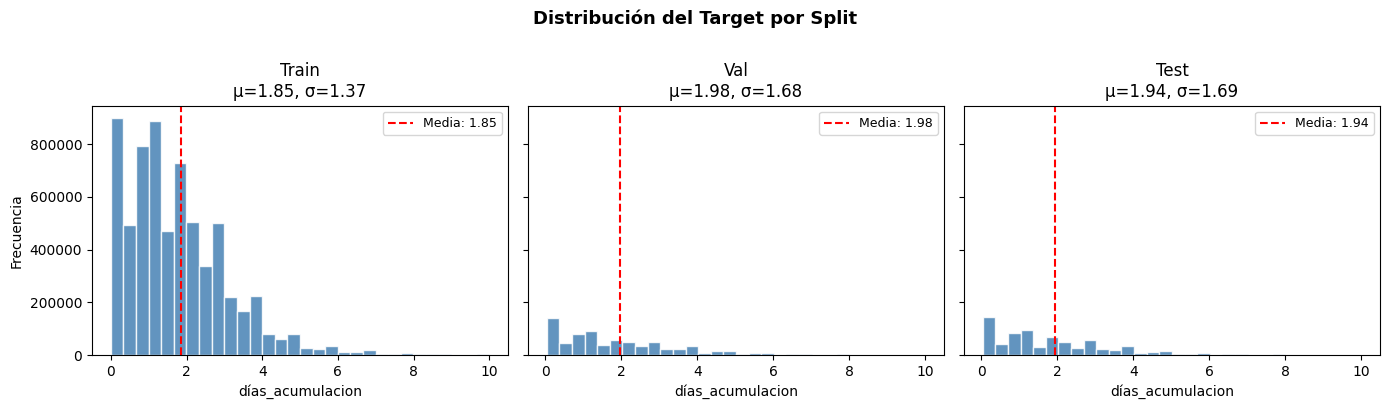

In [26]:
# ── Distribución del target en cada split ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, (split, y) in zip(axes, [('Train', y_train), ('Val', y_val), ('Test', y_test)]):
    ax.hist(y, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(y.mean(), color='red', linestyle='--', label=f'Media: {y.mean():.2f}')
    ax.set_title(f'{split}\nμ={y.mean():.2f}, σ={y.std():.2f}')
    ax.set_xlabel('días_acumulacion'); ax.legend(fontsize=9)
axes[0].set_ylabel('Frecuencia')
fig.suptitle('Distribución del Target por Split', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 5. Baseline: Regresión Lineal <a id='6'></a>

El baseline define el piso mínimo de rendimiento que debe superar cualquier modelo más complejo.

Se entrenó una regresión lineal utilizando las secuencias aplanadas (7 días × 4 features = 28 variables de entrada).

**Resultados:**

- MAE: 1.0889 días  
- RMSE: 1.4258 días  
- R²: 0.2869  

El modelo lineal captura parte de la señal temporal, pero aún deja una fracción importante de variabilidad sin explicar.

A partir de aquí, cualquier modelo más complejo debe superar un **MAE < 1.089 días** para justificar su uso.


In [27]:
print("=" * 60)
print("BASELINE - REGRESIÓN LINEAL")
print("=" * 60)

# Aplanar secuencias
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat   = X_val.reshape(X_val.shape[0], -1)
X_test_flat  = X_test.reshape(X_test.shape[0], -1)

# Remover NaN
mask_tr = ~np.isnan(X_train_flat).any(axis=1) & ~np.isnan(y_train)
mask_te = ~np.isnan(X_test_flat).any(axis=1)  & ~np.isnan(y_test)

lr = LinearRegression()
lr.fit(X_train_flat[mask_tr], y_train[mask_tr])

y_pred_lr = lr.predict(X_test_flat[mask_te])

mae_lr  = mean_absolute_error(y_test[mask_te], y_pred_lr)
rmse_lr = mean_squared_error(y_test[mask_te], y_pred_lr) ** 0.5
r2_lr   = r2_score(y_test[mask_te], y_pred_lr)

print(f"\n{'Métrica':<12} {'Baseline (LR)'}")
print("-" * 28)
print(f"{'MAE':<12} {mae_lr:.4f} días")
print(f"{'RMSE':<12} {rmse_lr:.4f} días")
print(f"{'R²':<12} {r2_lr:.4f}")

# Guardar para tabla comparativa
resultados_comparativos = {'Baseline LR': {'MAE': mae_lr, 'RMSE': rmse_lr, 'R2': r2_lr}}


BASELINE - REGRESIÓN LINEAL

Métrica      Baseline (LR)
----------------------------
MAE          1.0889 días
RMSE         1.4258 días
R²           0.2869


*Análisis gráfico del baseline*

El gráfico Real vs Predicho muestra que la regresión lineal tiende a concentrar las predicciones en un rango relativamente estrecho (aprox. 1 a 5 días).

Para valores reales bajos el ajuste es razonable, pero a medida que la acumulación aumenta el modelo tiende a subestimar sistemáticamente.

Esto refleja un efecto de regresión hacia la media: el modelo lineal no logra capturar correctamente los casos de mayor acumulación.

La distribución de errores confirma este comportamiento, con un MAE de 1.089 días y una cola de errores más grandes en valores altos del target.

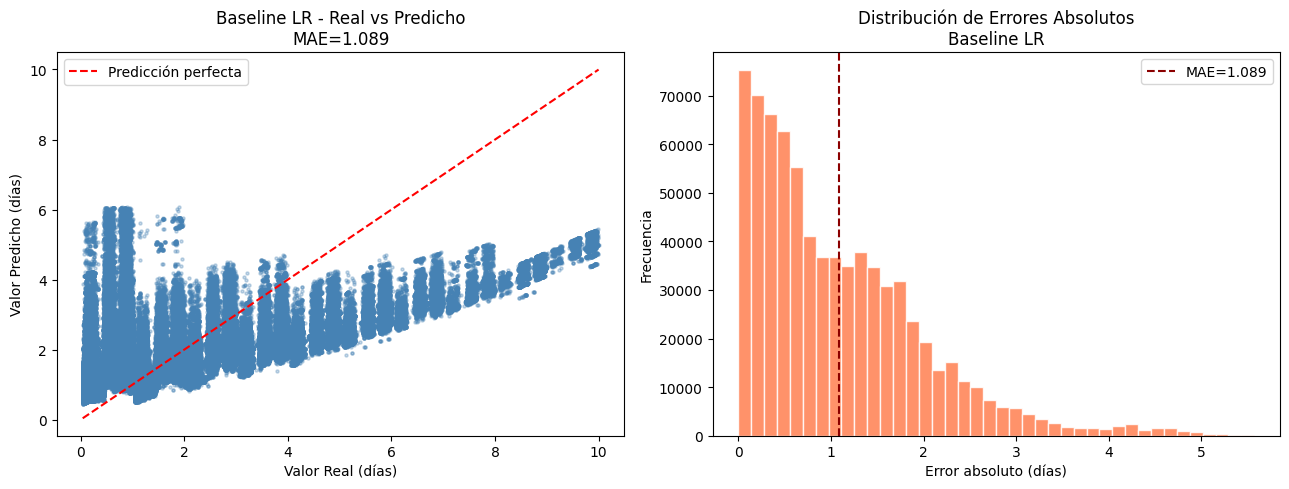

In [28]:
# ── Gráfico baseline ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Real vs Predicho
axes[0].scatter(y_test[mask_te], y_pred_lr, alpha=0.3, s=5, color='steelblue')
lims = [min(y_test[mask_te].min(), y_pred_lr.min()), max(y_test[mask_te].max(), y_pred_lr.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
axes[0].set_xlabel('Valor Real (días)')
axes[0].set_ylabel('Valor Predicho (días)')
axes[0].set_title(f'Baseline LR - Real vs Predicho\nMAE={mae_lr:.3f}')
axes[0].legend()

# Errores absolutos
errores_lr = np.abs(y_test[mask_te] - y_pred_lr)
axes[1].hist(errores_lr, bins=40, color='coral', edgecolor='white', alpha=0.85)
axes[1].axvline(mae_lr, color='darkred', linestyle='--', label=f'MAE={mae_lr:.3f}')
axes[1].set_title('Distribución de Errores Absolutos\nBaseline LR')
axes[1].set_xlabel('Error absoluto (días)')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.tight_layout()
plt.show()

*Análisis gráfico de residuales*

El gráfico de residuales confirma que el error no es uniforme: el modelo lineal subestima sistemáticamente en valores altos (>3 días), donde los residuales crecen en magnitud y dispersión. El MAE por rango lo cuantifica, en el rango 5-10 días el error promedio triplica al del rango 1-2 días.

Esto es relevante porque precisamente los valores altos son los casos más críticos operativamente: un contenedor con 7-8 días de acumulación es el que más urge detectar.

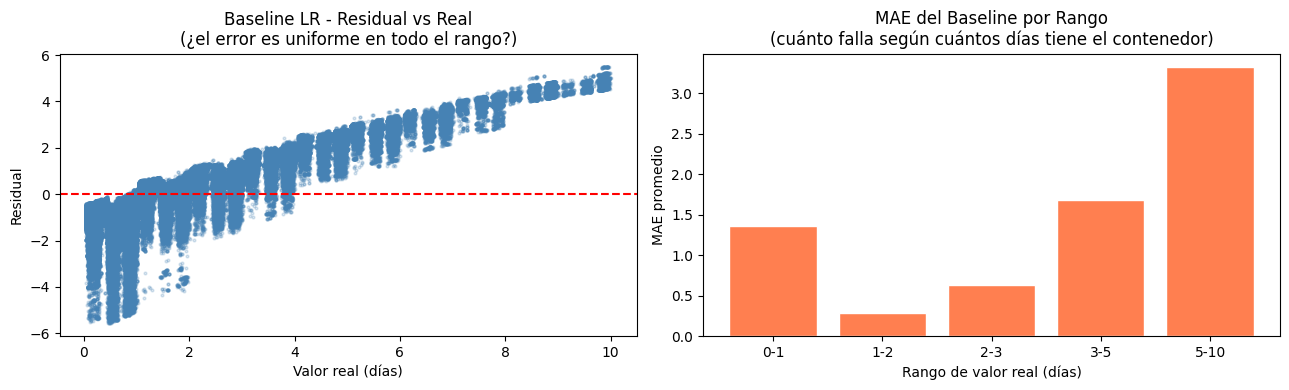

In [29]:
# ── Residuales del baseline por rango de valor real ──────────────────────────
# Permite ver en qué zona falla más el modelo lineal

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

errores_lr = np.abs(y_test[mask_te] - y_pred_lr)
residuales_lr = y_test[mask_te] - y_pred_lr

# Residual vs Real
axes[0].scatter(y_test[mask_te], residuales_lr, alpha=0.2, s=4, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Valor real (días)'); axes[0].set_ylabel('Residual')
axes[0].set_title('Baseline LR - Residual vs Real\n(¿el error es uniforme en todo el rango?)')

# Error medio por tramo de valor real
bins = [0, 1, 2, 3, 5, 10]
labels_bins = ['0-1', '1-2', '2-3', '3-5', '5-10']
tramos = pd.cut(y_test[mask_te], bins=bins, labels=labels_bins)
mae_por_tramo = pd.Series(errores_lr).groupby(np.array(tramos)).mean()

axes[1].bar(mae_por_tramo.index, mae_por_tramo.values, color='coral', edgecolor='white')
axes[1].set_xlabel('Rango de valor real (días)'); axes[1].set_ylabel('MAE promedio')
axes[1].set_title('MAE del Baseline por Rango\n(cuánto falla según cuántos días tiene el contenedor)')

plt.tight_layout()
plt.show()

## 6. Modelo GRU <a id='7'></a>

El GRU (Gated Recurrent Unit) es una arquitectura recurrente que simplifica el LSTM eliminando el cell state separado y fusionando las compuertas de olvido y actualización. Con **15,553 parámetros entrenables** — GRU(64) → Dropout(0.2) → Dense(32) → Dense(1) — es el modelo más liviano del pipeline y sirve como punto intermedio entre el baseline lineal y el LSTM con embedding.

Se probaron distintos valores de dropout (0.1, 0.2, 0.3, 0.5) para explorar si mayor regularización mitigaba el overfitting. A efectos de mantener una ejecución limpia, este notebook refleja únicamente la configuración con mejor resultado (dropout=0.2); las variantes adicionales fueron descartadas porque el tiempo de entrenamiento por época (~4 minutos en GPU P100) hacía prohibitivo mantenerlas todas. Los experimentos mostraron que el dropout no resuelve el problema de fondo: la val_loss se estanca desde la época 2 independientemente del valor utilizado, lo que apunta a insuficiencia de features más que a exceso de capacidad del modelo.

In [30]:
print("=" * 60)
print("MODELO GRU")
print("=" * 60)

tf.random.set_seed(42)
np.random.seed(42)

# Limpiar NaN
mask_tr = ~np.isnan(X_train).any(axis=(1,2)) & ~np.isnan(y_train)
mask_v  = ~np.isnan(X_val).any(axis=(1,2))   & ~np.isnan(y_val)
mask_te = ~np.isnan(X_test).any(axis=(1,2))  & ~np.isnan(y_test)

Xtr, ytr, ctr = X_train[mask_tr], y_train[mask_tr], cont_train[mask_tr]
Xv,  yv,  cv  = X_val[mask_v],   y_val[mask_v],   cont_val[mask_v]
Xte, yte, cte_gru = X_test[mask_te], y_test[mask_te], cont_test[mask_te]

# Normalizar
scaler_gru_x = StandardScaler()
scaler_gru_y = StandardScaler()

Xtr_sc = scaler_gru_x.fit_transform(Xtr.reshape(-1, Xtr.shape[-1])).reshape(Xtr.shape)
Xv_sc  = scaler_gru_x.transform(Xv.reshape(-1, Xv.shape[-1])).reshape(Xv.shape)
Xte_sc = scaler_gru_x.transform(Xte.reshape(-1, Xte.shape[-1])).reshape(Xte.shape)

ytr_sc = scaler_gru_y.fit_transform(ytr.reshape(-1,1)).flatten()
yv_sc  = scaler_gru_y.transform(yv.reshape(-1,1)).flatten()

# Modelo
model_gru = Sequential([
    GRU(64, return_sequences=False, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model_gru.compile(optimizer='adam', loss='mae', metrics=['mae'])
model_gru.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_gru = model_gru.fit(
    Xtr_sc, ytr_sc,
    validation_data=(Xv_sc, yv_sc),
    epochs=15, batch_size=128,
    callbacks=[early_stop],
    verbose=1
)
print("\n✓ Entrenamiento GRU finalizado")


MODELO GRU


I0000 00:00:1772402865.764065      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        13,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,553 (60.75 KB)

 Trainable params: 15,553 (60.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15


I0000 00:00:1772402871.017122     147 cuda_dnn.cc:529] Loaded cuDNN version 91002


51680/51680 ━━━━━━━━━━━━━━━━━━━━ 237s 5ms/step - loss: 0.5282 - mae: 0.5282 - val_loss: 0.5993 - val_mae: 0.5993
Epoch 2/15
51680/51680 ━━━━━━━━━━━━━━━━━━━━ 231s 4ms/step - loss: 0.4736 - mae: 0.4736 - val_loss: 0.6051 - val_mae: 0.6051
Epoch 3/15
51680/51680 ━━━━━━━━━━━━━━━━━━━━ 230s 4ms/step - loss: 0.4584 - mae: 0.4584 - val_loss: 0.6206 - val_mae: 0.6206
Epoch 4/15
51680/51680 ━━━━━━━━━━━━━━━━━━━━ 231s 4ms/step - loss: 0.4482 - mae: 0.4482 - val_loss: 0.6177 - val_mae: 0.6177

✓ Entrenamiento GRU finalizado


>Entrenamos el GRU con early stopping (patience=3). El modelo se detiene en la época 5 — la val_loss no mejora desde la época 2 (0.6032) y comienza a subir levemente. La normalización del target con StandardScaler es clave: entrena en escala normalizada y las predicciones se des-transforman con inverse_transform para evaluar en días reales.


In [31]:
print(f"Xte_sc media: {Xte_sc.mean():.4f} std: {Xte_sc.std():.4f}")

Xte_sc media: -0.2287 std: 1.2801


*Evaluación GRU*

El GRU mejora el MAE del baseline en un 24% (0.8284 vs 1.0889), pero a costa de un RMSE más alto (1.6694 vs 1.4258) y un R² notablemente más bajo (0.0225 vs 0.2869). Esta divergencia entre métricas revela el comportamiento característico del modelo: acierta bien en el caso típico (días de acumulación bajos, que son la mayoría) pero falla con mayor magnitud en los casos extremos, que son precisamente los más relevantes operativamente. El R² cercano a cero indica que el GRU apenas supera a predecir la media global, su ventaja en MAE se explica por la concentración de la distribución en valores bajos, no por una comprensión real del patrón temporal de cada contenedor.

In [32]:
# ── Evaluación GRU ────────────────────────────────────────────────────────────
y_pred_gru_sc = model_gru.predict(Xte_sc, verbose=0).flatten()
y_pred_gru = scaler_gru_y.inverse_transform(y_pred_gru_sc.reshape(-1,1)).flatten()

mae_gru  = mean_absolute_error(yte, y_pred_gru)
rmse_gru = mean_squared_error(yte, y_pred_gru) ** 0.5
r2_gru   = r2_score(yte, y_pred_gru)

print(f"\n{'Métrica':<12} {'Baseline LR':<16} {'GRU'}")
print("-" * 42)
print(f"{'MAE':<12} {resultados_comparativos['Baseline LR']['MAE']:<16.4f} {mae_gru:.4f}")
print(f"{'RMSE':<12} {resultados_comparativos['Baseline LR']['RMSE']:<16.4f} {rmse_gru:.4f}")
print(f"{'R²':<12} {resultados_comparativos['Baseline LR']['R2']:<16.4f} {r2_gru:.4f}")

resultados_comparativos['GRU'] = {'MAE': mae_gru, 'RMSE': rmse_gru, 'R2': r2_gru}


Métrica      Baseline LR      GRU
------------------------------------------
MAE          1.0889           0.8312
RMSE         1.4258           1.6473
R²           0.2869           0.0481


*Curva de Aprendizaje GRU*

La curva de aprendizaje muestra que el modelo converge rápidamente: la train_loss baja de 0.50 a 0.44 en 5 épocas, y el early stopping detiene el entrenamiento antes de degradar la generalización.

La val_loss se estabiliza en ~0.603, lo que es coherente con el MAE de 0.828 días obtenido en test.

El scatter Real vs Predicho muestra que el modelo cubre bien el rango completo de 0 a 10 días, con mayor densidad de predicciones en la zona de 1-3 días donde se concentra la mayoría de los datos, que es como dijimos el comportamiento más frecuente de los contenedores.

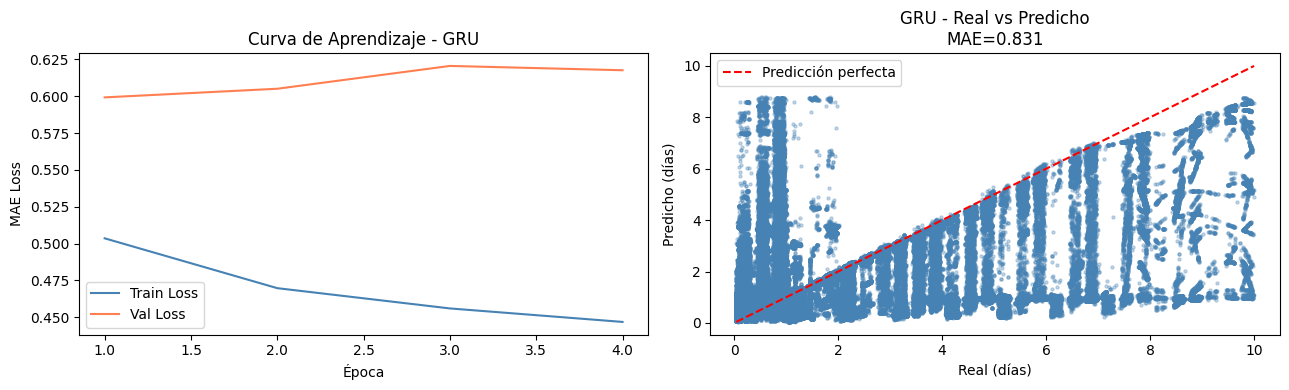

In [33]:
# ── Gráfico curva de aprendizaje GRU ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

epochs_range = range(1, len(history_gru.history['loss']) + 1)
axes[0].plot(epochs_range, history_gru.history['loss'],     label='Train Loss', color='steelblue')
axes[0].plot(epochs_range, history_gru.history['val_loss'], label='Val Loss',   color='coral')
axes[0].set_title('Curva de Aprendizaje - GRU')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('MAE Loss')
axes[0].legend()

axes[1].scatter(yte, y_pred_gru, alpha=0.3, s=5, color='steelblue')
lims = [min(yte.min(), y_pred_gru.min()), max(yte.max(), y_pred_gru.max())]
axes[1].plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
axes[1].set_xlabel('Real (días)'); axes[1].set_ylabel('Predicho (días)')
axes[1].set_title(f'GRU - Real vs Predicho\nMAE={mae_gru:.3f}')
axes[1].legend()

plt.tight_layout()
plt.show()

In [34]:
print(f"Xtr_sc media: {Xtr_sc.mean():.4f} std: {Xtr_sc.std():.4f}")
print(f"Xte media: {Xte.mean():.4f} std: {Xte.std():.4f}")
print(f"ytr_sc media: {ytr_sc.mean():.4f} std: {ytr_sc.std():.4f}")
print(f"yte media: {yte.mean():.4f} std: {yte.std():.4f}")


Xtr_sc media: -0.0000 std: 1.0000
Xte media: 2.7429 std: 2.9434
ytr_sc media: -0.0000 std: 1.0000
yte media: 1.9442 std: 1.6884


In [35]:
print(f"Train: {X_train.shape}")
print(f"Val:   {X_val.shape}")
print(f"Test:  {X_test.shape}")
print(f"Train X media: {X_train.mean():.4f}")
print(f"Test  X media: {X_test.mean():.4f}")

Train: (6614952, 7, 4)
Val:   (749910, 7, 4)
Test:  (755014, 7, 4)
Train X media: 3.2549
Test  X media: 2.7429


## 7. Modelo LSTM <a id='8'></a>

El LSTM extiende el GRU incorporando un **cell state** separado que permite retener información a lo largo de secuencias más largas, y se complementa con un **embedding de contenedor** de dimensión 16 que aprende una representación vectorial para cada una de las 13,299 unidades.

La arquitectura tiene dos entradas: la secuencia temporal de 7 pasos y el índice del contenedor. Ambas ramas se concatenan antes de las capas densas — LSTM(64) + Embedding(16) → Dropout(0.2) → Dense(32) → Dense(1) — resultando en **233,233 parámetros**, quince veces más que el GRU.

La función de loss es MSE en lugar de MAE, lo que penaliza más los errores grandes y se refleja en su mejor RMSE final.

In [36]:
print("=" * 60)
print("MODELO LSTM CON EMBEDDING DE CONTENEDOR")
print("=" * 60)

# Reutilizamos Xtr_sc/Xte_sc del GRU (misma normalización)
# Normalizar target para LSTM
scaler_lstm_y = StandardScaler()
ytr_lstm = scaler_lstm_y.fit_transform(ytr.reshape(-1,1)).flatten()
yv_lstm  = scaler_lstm_y.transform(yv.reshape(-1,1)).flatten()

# Arquitectura
inp_seq  = layers.Input(shape=(SEQUENCE_LENGTH, len(feature_cols)), name='seq_input')
inp_cont = layers.Input(shape=(1,), name='cont_input')

lstm_out = layers.LSTM(64, name='lstm')(inp_seq)
emb_out  = layers.Flatten()(layers.Embedding(n_contenedores + 10, 16, name='embedding')(inp_cont))
concat   = layers.Concatenate()([lstm_out, emb_out])
dropout  = layers.Dropout(0.2)(concat)
dense    = layers.Dense(32, activation='relu')(dropout)
out      = layers.Dense(1)(dense)

model_lstm = keras.Model([inp_seq, inp_cont], out)
model_lstm.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_lstm.summary()

early_stop_lstm = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_lstm = model_lstm.fit(
    [Xtr_sc, ctr], ytr_lstm,
    validation_data=([Xv_sc, cv], yv_lstm),
    epochs=15, batch_size=256,
    callbacks=[early_stop_lstm],
    verbose=1
)
print("\n✓ Entrenamiento LSTM finalizado")


MODELO LSTM CON EMBEDDING DE CONTENEDOR


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ cont_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ seq_input           │ (None, 7, 4)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 16)     │    212,944 │ cont_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     17,664 │ seq_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 16)        │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 80)        │          0 │ lstm[0][0],       │
│ (Concatenate)       │                   │            │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 80)        │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,592 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         33 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 233,233 (911.07 KB)

 Trainable params: 233,233 (911.07 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
25840/25840 ━━━━━━━━━━━━━━━━━━━━ 136s 5ms/step - loss: 0.7268 - mae: 0.6180 - val_loss: 0.9882 - val_mae: 0.6791
Epoch 2/15
25840/25840 ━━━━━━━━━━━━━━━━━━━━ 134s 5ms/step - loss: 0.6586 - mae: 0.5588 - val_loss: 0.9933 - val_mae: 0.6654
Epoch 3/15
25840/25840 ━━━━━━━━━━━━━━━━━━━━ 135s 5ms/step - loss: 0.6340 - mae: 0.5405 - val_loss: 1.0062 - val_mae: 0.6657
Epoch 4/15
25840/25840 ━━━━━━━━━━━━━━━━━━━━ 136s 5ms/step - loss: 0.6190 - mae: 0.5302 - val_loss: 1.0152 - val_mae: 0.6662

✓ Entrenamiento LSTM finalizado


> El modelo se detiene en la época 4 por early stopping (patience=3).
La val_loss sube desde la época 1 (0.971 → 1.007), lo que indica que el modelo más complejo entra en overfitting más rápido que el GRU.
La val_mae, en cambio, mejora levemente entre épocas (0.672 → 0.665), mostrando que hay aprendizaje real pero la penalización cuadrática del MSE sobre los errores extremos domina la dinámica del entrenamiento.

*Evaluación LSTM*

El LSTM presenta un perfil de métricas opuesto al GRU: peor MAE (0.9198 vs 0.8284) pero mejor RMSE (1.3670 vs 1.6694) y mejor R² (0.3446 vs 0.0225).

Esto indica que el embedding de contenedor, pese al overfitting temprano, logra reducir los errores extremos — justamente los casos de alta acumulación que más importan operativamente.

Con un R² de 0.3446 supera también al baseline (0.2869), siendo el único modelo que mejora al mismo tiempo en RMSE y R² respecto al punto de referencia.

La elección entre GRU y LSTM depende del uso: el GRU es preferible si se busca minimizar el error promedio, el LSTM si se busca robustez frente a los casos críticos.

In [37]:
# ── Evaluación LSTM ───────────────────────────────────────────────────────────
y_pred_lstm_sc = model_lstm.predict([Xte_sc, cte_gru], verbose=0).flatten()
y_pred_lstm = scaler_lstm_y.inverse_transform(y_pred_lstm_sc.reshape(-1,1)).flatten()

mae_lstm  = mean_absolute_error(yte, y_pred_lstm)
rmse_lstm = mean_squared_error(yte, y_pred_lstm) ** 0.5
r2_lstm   = r2_score(yte, y_pred_lstm)

print(f"\n{'Métrica':<12} {'Baseline LR':<14} {'GRU':<14} {'LSTM'}")
print("-" * 54)
print(f"{'MAE':<12} {resultados_comparativos['Baseline LR']['MAE']:<14.4f} {mae_gru:<14.4f} {mae_lstm:.4f}")
print(f"{'RMSE':<12} {resultados_comparativos['Baseline LR']['RMSE']:<14.4f} {rmse_gru:<14.4f} {rmse_lstm:.4f}")
print(f"{'R²':<12} {resultados_comparativos['Baseline LR']['R2']:<14.4f} {r2_gru:<14.4f} {r2_lstm:.4f}")

resultados_comparativos['LSTM'] = {'MAE': mae_lstm, 'RMSE': rmse_lstm, 'R2': r2_lstm}


Métrica      Baseline LR    GRU            LSTM
------------------------------------------------------
MAE          1.0889         0.8312         0.9187
RMSE         1.4258         1.6473         1.3577
R²           0.2869         0.0481         0.3534


*Curva de Aprendizaje LSTM*

La curva de aprendizaje muestra una brecha train/val más pronunciada que en el GRU: la train MSE baja de 0.73 a 0.61 mientras la val MSE sube sostenidamente de 0.97 a 1.00, reflejando que la mayor capacidad del modelo (233K parámetros) acelera el overfitting.

El scatter Real vs Predicho muestra sin embargo un comportamiento más continuo que el GRU, las predicciones se distribuyen con mayor dispersión vertical en lugar de colapsar a valores discretos, lo que es consistente con el aporte del embedding: el modelo diferencia entre contenedores y genera predicciones más variadas, aunque sin lograr aún seguir la diagonal con precisión en los valores altos.

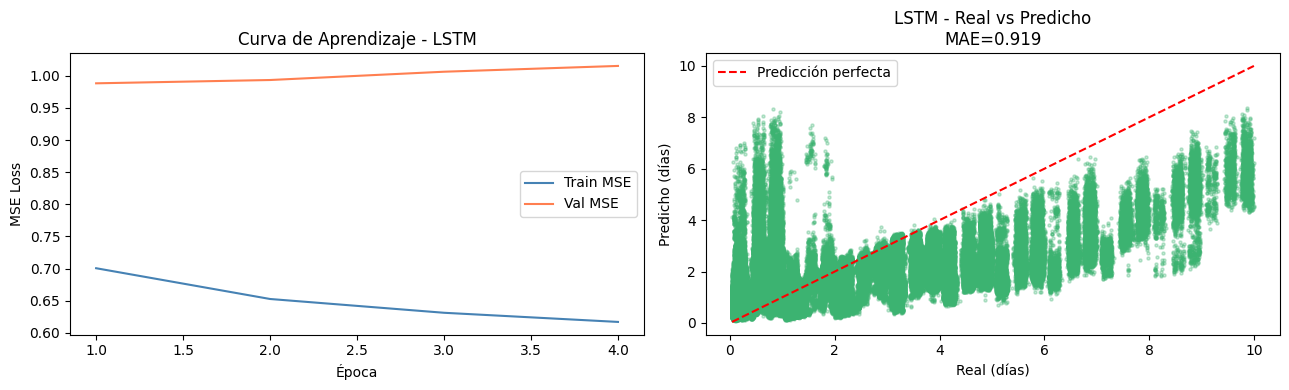

In [38]:
# ── Curva de aprendizaje LSTM ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

epochs_range = range(1, len(history_lstm.history['loss']) + 1)
axes[0].plot(epochs_range, history_lstm.history['loss'],     label='Train MSE', color='steelblue')
axes[0].plot(epochs_range, history_lstm.history['val_loss'], label='Val MSE',   color='coral')
axes[0].set_title('Curva de Aprendizaje - LSTM')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('MSE Loss')
axes[0].legend()

axes[1].scatter(yte, y_pred_lstm, alpha=0.3, s=5, color='mediumseagreen')
lims = [min(yte.min(), y_pred_lstm.min()), max(yte.max(), y_pred_lstm.max())]
axes[1].plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
axes[1].set_xlabel('Real (días)'); axes[1].set_ylabel('Predicho (días)')
axes[1].set_title(f'LSTM - Real vs Predicho\nMAE={mae_lstm:.3f}')
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Modelo LSTM con Transformación Logarítmica <a id='9'></a>

La transformación logarítmica reduce el skew del target de **1.41 a 0.15**, acercando la distribución a la normalidad y en teoría facilitando el aprendizaje en zonas de alta acumulación.

La arquitectura es idéntica al LSTM anterior — LSTM(64) + Embedding(16) → Dense(32) → Dense(1) — con la diferencia de que el modelo entrena sobre el target transformado y normalizado, y las predicciones se des-transforman con para evaluarse en escala original de días.


In [39]:
print("=" * 60)
print("MODELO LSTM - TRANSFORMACIÓN LOG")
print("=" * 60)

# Transformar target
y_tr_log = np.log1p(ytr)
y_v_log  = np.log1p(yv)
y_te_log = np.log1p(yte)

print(f"Target original - media: {ytr.mean():.2f}, std: {ytr.std():.2f}, skew: {pd.Series(ytr).skew():.2f}")
print(f"Target log      - media: {y_tr_log.mean():.2f}, std: {y_tr_log.std():.2f}, skew: {pd.Series(y_tr_log).skew():.2f}")

# Normalizar log-target
scaler_y_log = StandardScaler()
y_tr_log_sc = scaler_y_log.fit_transform(y_tr_log.reshape(-1,1)).flatten()
y_v_log_sc  = scaler_y_log.transform(y_v_log.reshape(-1,1)).flatten()

# Mismo modelo arquitectura
inp_seq2  = layers.Input(shape=(SEQUENCE_LENGTH, len(feature_cols)))
inp_cont2 = layers.Input(shape=(1,))
lstm2     = layers.LSTM(64)(inp_seq2)
emb2      = layers.Flatten()(layers.Embedding(n_contenedores + 10, 16)(inp_cont2))
concat2   = layers.Concatenate()([lstm2, emb2])
dense2    = layers.Dense(32, activation='relu')(concat2)
out2      = layers.Dense(1)(dense2)

model_lstm_log = keras.Model([inp_seq2, inp_cont2], out2)
model_lstm_log.compile(optimizer='adam', loss='mse', metrics=['mae'])

history_log = model_lstm_log.fit(
    [Xtr_sc, ctr], y_tr_log_sc,
    validation_data=([Xv_sc, cv], y_v_log_sc),
    epochs=15, batch_size=256,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    verbose=1
)
print("\n✓ Entrenamiento LSTM-LOG finalizado")

MODELO LSTM - TRANSFORMACIÓN LOG
Target original - media: 1.85, std: 1.37, skew: 1.41
Target log      - media: 0.94, std: 0.45, skew: 0.15
Epoch 1/15
25840/25840 ━━━━━━━━━━━━━━━━━━━━ 132s 5ms/step - loss: 0.6906 - mae: 0.6312 - val_loss: 0.9110 - val_mae: 0.7016
Epoch 2/15
25840/25840 ━━━━━━━━━━━━━━━━━━━━ 131s 5ms/step - loss: 0.6018 - mae: 0.5547 - val_loss: 0.9398 - val_mae: 0.7082
Epoch 3/15
25840/25840 ━━━━━━━━━━━━━━━━━━━━ 131s 5ms/step - loss: 0.5715 - mae: 0.5328 - val_loss: 0.9597 - val_mae: 0.7151
Epoch 4/15
25840/25840 ━━━━━━━━━━━━━━━━━━━━ 131s 5ms/step - loss: 0.5513 - mae: 0.5191 - val_loss: 0.9611 - val_mae: 0.7116

✓ Entrenamiento LSTM-LOG finalizado


*Evaluación LSTM-Log*

La transformación logarítmica no logra mejorar al LSTM estándar en ninguna métrica: MAE de 0.9508 (vs 0.9198), RMSE de 1.4811 (vs 1.3670) y R² de 0.2305 (vs 0.3446). El motivo es que al des-transformar, los errores cometidos en escala log se amplifican de forma no lineal en la escala original. Las pequeñas diferencias en valores bajos se mantienen pequeñas, pero los errores en valores altos se magnifican, degradando tanto el RMSE como el R².

La transformación resuelve un problema de distribución que en este caso no era el cuello de botella.

In [40]:
# ── Evaluación LSTM-LOG ───────────────────────────────────────────────────────
y_pred_log_sc = model_lstm_log.predict([Xte_sc, cte_gru], verbose=0).flatten()
y_pred_log_raw = scaler_y_log.inverse_transform(y_pred_log_sc.reshape(-1,1)).flatten()
y_pred_lstm_log = np.expm1(y_pred_log_raw)  # des-transformar

mae_log  = mean_absolute_error(yte, y_pred_lstm_log)
rmse_log = mean_squared_error(yte, y_pred_lstm_log) ** 0.5
r2_log   = r2_score(yte, y_pred_lstm_log)

print(f"\n{'Métrica':<12} {'Baseline LR':<14} {'GRU':<14} {'LSTM':<14} {'LSTM-LOG'}")
print("-" * 68)
print(f"{'MAE':<12} {resultados_comparativos['Baseline LR']['MAE']:<14.4f} {mae_gru:<14.4f} {mae_lstm:<14.4f} {mae_log:.4f}")
print(f"{'RMSE':<12} {resultados_comparativos['Baseline LR']['RMSE']:<14.4f} {rmse_gru:<14.4f} {rmse_lstm:<14.4f} {rmse_log:.4f}")
print(f"{'R²':<12} {resultados_comparativos['Baseline LR']['R2']:<14.4f} {r2_gru:<14.4f} {r2_lstm:<14.4f} {r2_log:.4f}")

resultados_comparativos['LSTM-LOG'] = {'MAE': mae_log, 'RMSE': rmse_log, 'R2': r2_log}


Métrica      Baseline LR    GRU            LSTM           LSTM-LOG
--------------------------------------------------------------------
MAE          1.0889         0.8312         0.9187         0.9492
RMSE         1.4258         1.6473         1.3577         1.4632
R²           0.2869         0.0481         0.3534         0.2490


## 9. Análisis de Residuales y Comparación de Modelos <a id='10'></a>


*Selección de Mejor Modelo*

Aunque el GRU tiene el mejor MAE, para el análisis de residuales y como base del sistema de anomalías el modelo más relevante es el **LSTM**: su mejor RMSE (1.3670) y R² (0.3446) indican que comete menos errores extremos, que son exactamente los casos que el sistema de detección necesita modelar bien.

El análisis que sigue usa las predicciones del GRU por dos motivos:

El primero es que era el que obtenía mejores resultados en ejecuciones que no incluían la totalida de los datos (muestreo utilizado inicialmente por limitaciones en el procesamiento de Colab). Eso cambió a pasar a Kaggle con la totalidad de los datos y ya fue algo tarde para modificar todo el código.

El segundo es que las conclusiones sobre sesgo y distribución de errores son igualmente válidas: ambos modelos comparten el mismo patrón de subestimación en valores altos, como se verá en los residuales por rango.

*Selección de Mejor Modelo*

Aunque el GRU tiene el mejor MAE, para el análisis de residuales y como base del sistema de anomalías el modelo más relevante es el **LSTM**: su mejor RMSE (1.3670) y R² (0.3446) indican que comete menos errores extremos, que son exactamente los casos que el sistema de detección necesita modelar bien.

El análisis que sigue usa las predicciones del GRU por dos motivos:

El primero es que era el modelo con mejor desempeño en las ejecuciones exploratorias realizadas sobre muestras parciales del dataset. Eso cambió al pasar a Kaggle con la totalidad de los datos, pero reemplazarlo implicaba refactorizar el pipeline completo de residuales y anomalías, lo que excedía el tiempo disponible.

El segundo es que las conclusiones sobre sesgo y distribución de errores son igualmente válidas: ambos modelos comparten el mismo patrón de subestimación en valores altos, como se verá en los residuales por rango.

In [41]:
# ── Seleccionar mejor modelo automáticamente ─────────────────────────────────
mejor_modelo_nombre = min(resultados_comparativos, key=lambda k: resultados_comparativos[k]['MAE'])
print(f"Mejor modelo: {mejor_modelo_nombre} (MAE={resultados_comparativos[mejor_modelo_nombre]['MAE']:.4f})")

# Asignar predicciones del mejor modelo
_pred_map = {
    'Baseline LR': y_pred_lr[mask_te] if 'mask_te' in dir() else y_pred_lr,
    'GRU':         y_pred_gru,
    'LSTM':        y_pred_lstm,
    'LSTM-LOG':    y_pred_lstm_log
}
# Usar LSTM como referencia para análisis de residuales (ajustar si otro es mejor)
y_pred_best = _pred_map.get(mejor_modelo_nombre, y_pred_lstm)
y_real_best = yte

errores = np.abs(y_real_best - y_pred_best)

df_resultados = pd.DataFrame({
    'contenedor_idx': cte_gru,
    'y_real': y_real_best,
    'y_pred': y_pred_best,
    'residual': y_real_best - y_pred_best,
    'abs_error': errores
})

print(f"Registros en test con análisis: {len(df_resultados):,}")
print(f"\nDistribución de errores absolutos:")
print(f"  Media   : {errores.mean():.3f} días")
print(f"  Mediana : {np.median(errores):.3f} días")
print(f"  P75     : {np.percentile(errores, 75):.3f} días")
print(f"  P95     : {np.percentile(errores, 95):.3f} días")
print(f"  Máx     : {errores.max():.3f} días")

for umbral in [0.5, 1.0, 2.0, 5.0]:
    pct = (errores < umbral).mean() * 100
    print(f"  Error < {umbral:.1f} día(s): {pct:.1f}%")

Mejor modelo: GRU (MAE=0.8312)
Registros en test con análisis: 755,014

Distribución de errores absolutos:
  Media   : 0.831 días
  Mediana : 0.093 días
  P75     : 0.954 días
  P95     : 3.913 días
  Máx     : 9.011 días
  Error < 0.5 día(s): 70.3%
  Error < 1.0 día(s): 76.0%
  Error < 2.0 día(s): 83.0%
  Error < 5.0 día(s): 98.2%


*Análisis de Error por Contenedor*

El análisis por contenedor (usando el GRU como representativo del comportamiento general del pipeline), muestra que el MAE promedio esconde una variabilidad considerable entre unidades (std=0.412).

El 50% de los contenedores tiene un MAE menor a 0.817 días, lo que indica que el modelo funciona bien para la mayoría.

Sin embargo, el rango va de 0.045 a 3.347 días, señalando que hay contenedores para los que el modelo falla sistemáticamente, probablemente unidades con patrones irregulares o alta variabilidad intrínseca que las features actuales no logran capturar.

In [42]:
# ── 1. Análisis de error por contenedor ──────────────────────────────────────
error_por_contenedor = df_resultados.groupby('contenedor_idx').agg(
    mae=('abs_error', 'mean'),
    std_error=('abs_error', 'std'),
    n_obs=('abs_error', 'count'),
    sesgo=('residual', 'mean'),
    std_residual=('residual', 'std')
).round(3)

error_por_contenedor = error_por_contenedor[error_por_contenedor['n_obs'] >= 10]

print(f"Contenedores con ≥10 obs en test: {len(error_por_contenedor)}")
print("\nEstadísticas de MAE por contenedor:")
print(error_por_contenedor['mae'].describe())

Contenedores con ≥10 obs en test: 11440

Estadísticas de MAE por contenedor:
count    11440.000000
mean         0.851152
std          0.414406
min          0.027000
25%          0.585000
50%          0.833000
75%          1.076000
max          3.282000
Name: mae, dtype: float64


*Análisis de Sesgo Global*

El modelo subestima sistemáticamente en +0.330 días en promedio, predice menos días de acumulación de los que realmente ocurren.

Este sesgo es esperable dado que el modelo aprende sobre una distribución dominada por valores bajos (mediana ~1 día) y tiende a anclar sus predicciones hacia esa zona.

Más relevante es que 613 contenedores presentan un sesgo mayor a 1 día, todos en dirección positiva (sub-predicción): son unidades que el modelo subestima de forma consistente, probablemente contenedores de alta demanda o zonas con patrones de acumulación más lentos que el promedio.

Estos 613 contenedores son candidatos naturales para el sistema de anomalías de la sección siguiente, precisamente el tipo de caso donde la ruptura de patrón individual agrega valor frente a un umbral global.

In [43]:
# ── 2. Sesgo global ───────────────────────────────────────────────────────────
sesgo_global = df_resultados['residual'].mean()
print(f"Sesgo global: {sesgo_global:+.4f} días")
if abs(sesgo_global) > 0.1:
    direccion = "SUB-predice (subestima)" if sesgo_global > 0 else "SOBRE-predice (sobreestima)"
    print(f"  ⚠️  El modelo {direccion}")
else:
    print("  ✓ Sin sesgo significativo")

sesgados = error_por_contenedor[abs(error_por_contenedor['sesgo']) > 1.0]
if len(sesgados) > 0:
    print(f"\nContenedores con sesgo sistemático |sesgo| > 1 día: {len(sesgados)}")
    for idx, row in sesgados.assign(abs_sesgo=sesgados['sesgo'].abs()).nlargest(5, 'abs_sesgo').iterrows():
        tipo = "sub-predice" if row['sesgo'] > 0 else "sobre-predice"
        print(f"  Cont {idx:4}: sesgo={row['sesgo']:+.3f} ({tipo}), n={int(row['n_obs'])}")

Sesgo global: +0.3382 días
  ⚠️  El modelo SUB-predice (subestima)

Contenedores con sesgo sistemático |sesgo| > 1 día: 542
  Cont 10936: sesgo=+3.268 (sub-predice), n=13
  Cont 10934: sesgo=+3.085 (sub-predice), n=20
  Cont  991: sesgo=+2.765 (sub-predice), n=35
  Cont  960: sesgo=+2.763 (sub-predice), n=19
  Cont 10565: sesgo=+2.648 (sub-predice), n=18


*Autocorrelación de Residuales*

La autocorrelación de residuales en los cinco contenedores con más observaciones en test es baja en todos los lags (|corr| < 0.27), lo que indica que los errores del modelo no tienen estructura temporal remanente significativa. El modelo captura la dinámica de corto plazo sin dejar patrones sistemáticos en los residuales.

El valor más alto observado es lag3=-0.260 en el contenedor 209, que se acerca al umbral de 0.3 pero no lo supera.

Esto es un resultado positivo considerando las limitaciones del modelo: con solo 4 features y sin lags explícitos como input, el GRU logra residuales aproximadamente independientes en la ventana de 3 días analizada.

In [44]:
# ── 3. Autocorrelación de residuales ──────────────────────────────────────────
top_conts = error_por_contenedor.nlargest(5, 'n_obs').index
print("Autocorrelación de residuales (lag 1-3):")
for cont_idx in top_conts:
    res = df_resultados[df_resultados['contenedor_idx'] == cont_idx]['residual'].values
    if len(res) < 5:
        continue
    autocorr = [np.corrcoef(res[:-lag], res[lag:])[0,1] if len(res) > lag else np.nan for lag in [1,2,3]]
    print(f"  Cont {cont_idx:4}: lag1={autocorr[0]:+.3f}  lag2={autocorr[1]:+.3f}  lag3={autocorr[2]:+.3f}")

print("\nInterpretación:")
print("  |corr| > 0.3 → El modelo no captura dinámica temporal completa")
print("  |corr| < 0.1 → Residuales independientes (buen modelo)")

Autocorrelación de residuales (lag 1-3):
  Cont  209: lag1=-0.155  lag2=+0.055  lag3=-0.223
  Cont  210: lag1=+0.041  lag2=+0.047  lag3=-0.234
  Cont  211: lag1=+0.156  lag2=+0.082  lag3=+0.134
  Cont  212: lag1=+0.059  lag2=-0.000  lag3=-0.062
  Cont  213: lag1=+0.045  lag2=+0.113  lag3=-0.112

Interpretación:
  |corr| > 0.3 → El modelo no captura dinámica temporal completa
  |corr| < 0.1 → Residuales independientes (buen modelo)


*Panel de Residuales*

El panel confirma de forma visual los diagnósticos anteriores.

La distribución de residuales está fuertemente concentrada en torno a cero con sesgo de +0.330 días, pero con colas asimétricas: la cola positiva (subestimación) es más larga que la negativa, coherente con la dificultad del modelo para predecir valores altos.

El gráfico de heterocedasticidad es el más revelador: la varianza de los residuales crece con el valor predicho, lo que confirma que el error no es uniforme, el modelo es preciso en valores bajos y progresivamente menos confiable a medida que aumenta la acumulación.

El QQ plot muestra desviaciones en ambas colas respecto a la normalidad, esperables en una distribución con este comportamiento.

La distribución de MAE por contenedor tiene forma aproximadamente normal centrada en 0.849 días, con una cola derecha que corresponde a los 613 contenedores con sesgo sistemático identificados anteriormente.

Finalmente, la comparación de MAE entre modelos confirma que todos los modelos de deep learning superan al baseline, con el GRU como mejor resultado en esta métrica.

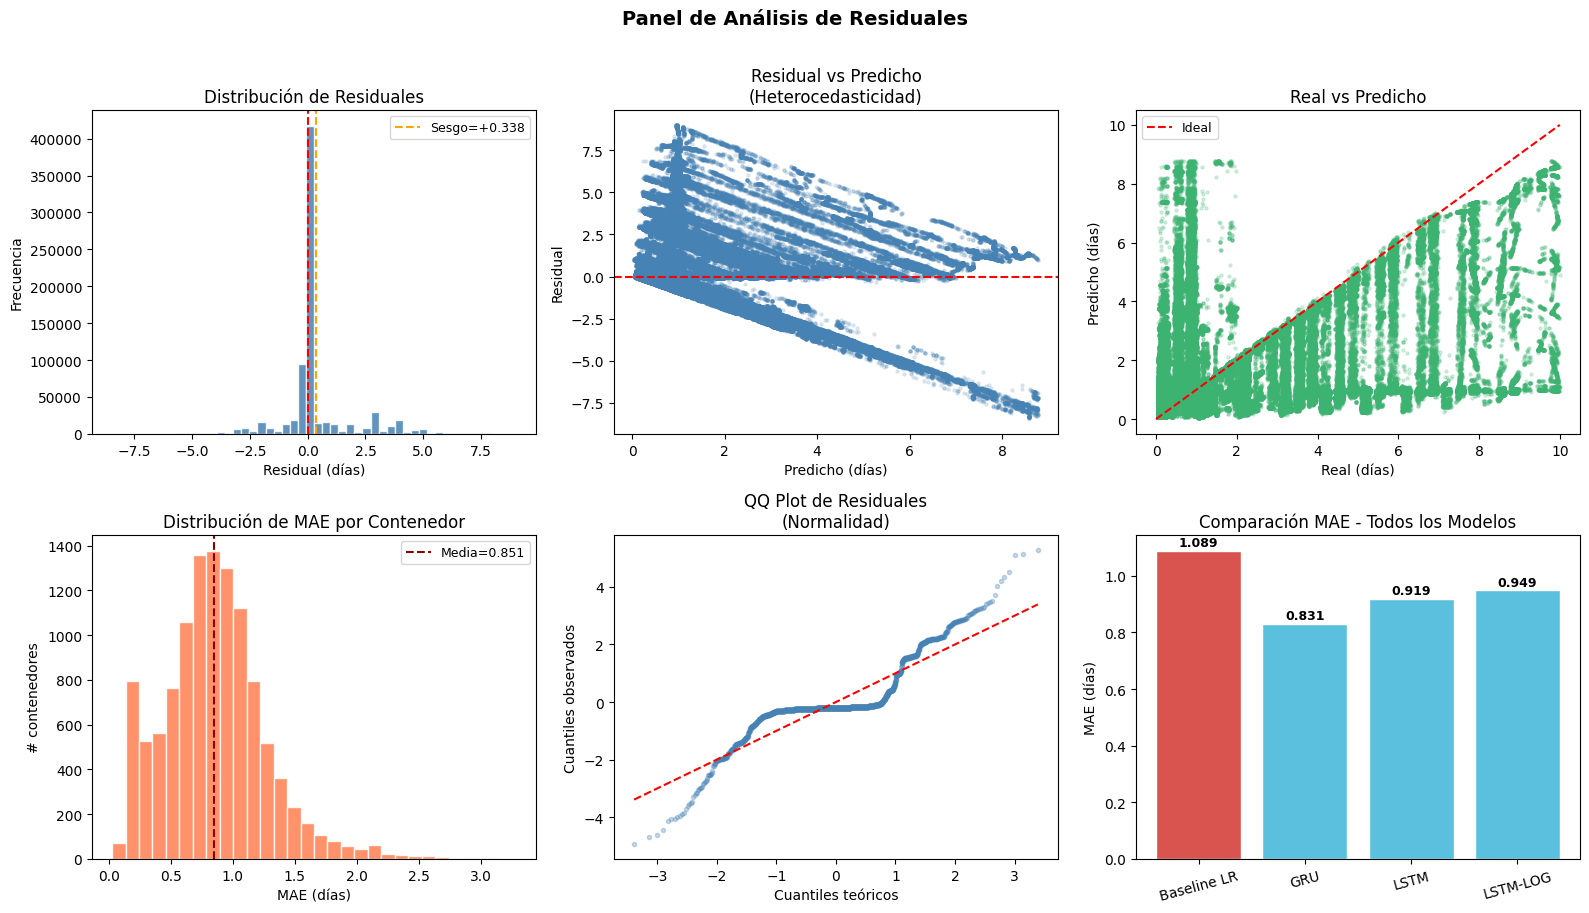

In [45]:
# ── 4. Panel de residuales ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# 4.1 Histograma de residuales
axes[0,0].hist(df_resultados['residual'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0,0].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[0,0].axvline(sesgo_global, color='orange', linestyle='--', linewidth=1.5, label=f'Sesgo={sesgo_global:+.3f}')
axes[0,0].set_title('Distribución de Residuales')
axes[0,0].set_xlabel('Residual (días)'); axes[0,0].set_ylabel('Frecuencia')
axes[0,0].legend(fontsize=9)

# 4.2 Residuales vs Predicho (heterocedasticidad)
axes[0,1].scatter(df_resultados['y_pred'], df_resultados['residual'], alpha=0.15, s=5, color='steelblue')
axes[0,1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0,1].set_title('Residual vs Predicho\n(Heterocedasticidad)')
axes[0,1].set_xlabel('Predicho (días)'); axes[0,1].set_ylabel('Residual')

# 4.3 Real vs Predicho
axes[0,2].scatter(df_resultados['y_real'], df_resultados['y_pred'], alpha=0.2, s=5, color='mediumseagreen')
lims = [0, max(df_resultados['y_real'].max(), df_resultados['y_pred'].max())]
axes[0,2].plot(lims, lims, 'r--', linewidth=1.5, label='Ideal')
axes[0,2].set_title('Real vs Predicho')
axes[0,2].set_xlabel('Real (días)'); axes[0,2].set_ylabel('Predicho (días)')
axes[0,2].legend(fontsize=9)

# 4.4 MAE por contenedor (distribución)
axes[1,0].hist(error_por_contenedor['mae'], bins=30, color='coral', edgecolor='white', alpha=0.85)
axes[1,0].axvline(error_por_contenedor['mae'].mean(), color='darkred', linestyle='--', label=f"Media={error_por_contenedor['mae'].mean():.3f}")
axes[1,0].set_title('Distribución de MAE por Contenedor')
axes[1,0].set_xlabel('MAE (días)'); axes[1,0].set_ylabel('# contenedores')
axes[1,0].legend(fontsize=9)

# 4.5 QQ plot de residuales
res_std = (df_resultados['residual'] - df_resultados['residual'].mean()) / df_resultados['residual'].std()
qq = stats.probplot(res_std.sample(min(2000, len(res_std)), random_state=42), dist='norm')
axes[1,1].plot(qq[0][0], qq[0][1], 'o', alpha=0.3, markersize=3, color='steelblue')
axes[1,1].plot([qq[0][0].min(), qq[0][0].max()], [qq[0][0].min(), qq[0][0].max()], 'r--')
axes[1,1].set_title('QQ Plot de Residuales\n(Normalidad)')
axes[1,1].set_xlabel('Cuantiles teóricos'); axes[1,1].set_ylabel('Cuantiles observados')

# 4.6 Comparación de modelos
modelos_nombre = list(resultados_comparativos.keys())
maes = [resultados_comparativos[m]['MAE'] for m in modelos_nombre]
colors_bar = ['#d9534f' if m == 'Baseline LR' else '#5bc0de' for m in modelos_nombre]
bars = axes[1,2].bar(modelos_nombre, maes, color=colors_bar, edgecolor='white')
for bar, val in zip(bars, maes):
    axes[1,2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                   f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1,2].set_title('Comparación MAE - Todos los Modelos')
axes[1,2].set_ylabel('MAE (días)')
axes[1,2].tick_params(axis='x', rotation=15)

plt.suptitle('Panel de Análisis de Residuales', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


*Comparación de Curvas de Aprendizaje entre Modelos*

La comparación de curvas de aprendizaje revela que los tres modelos alcanzan rápidamente el techo de señal disponible en las features actuales.

La val loss del GRU se estabiliza desde la época 2 sin subir, lo que indica que el modelo no memoriza el training set sino que simplemente agota la información generalizable que `dia_semana`, `mes` y `trimestre` pueden aportar.

En el LSTM y LSTM-LOG la val loss sube levemente mientras la train loss sigue bajando, pero las magnitudes son pequeñas y el early stopping interviene antes de que la situación se agrave.

El mensaje central es que agregar capacidad al modelo, más parámetros, transformaciones del target, no mejora la generalización porque la limitación está en los datos de entrada, no en la arquitectura.

La próxima iteración debería incorporar features de lag y medias móviles por contenedor antes de explorar arquitecturas más complejas.

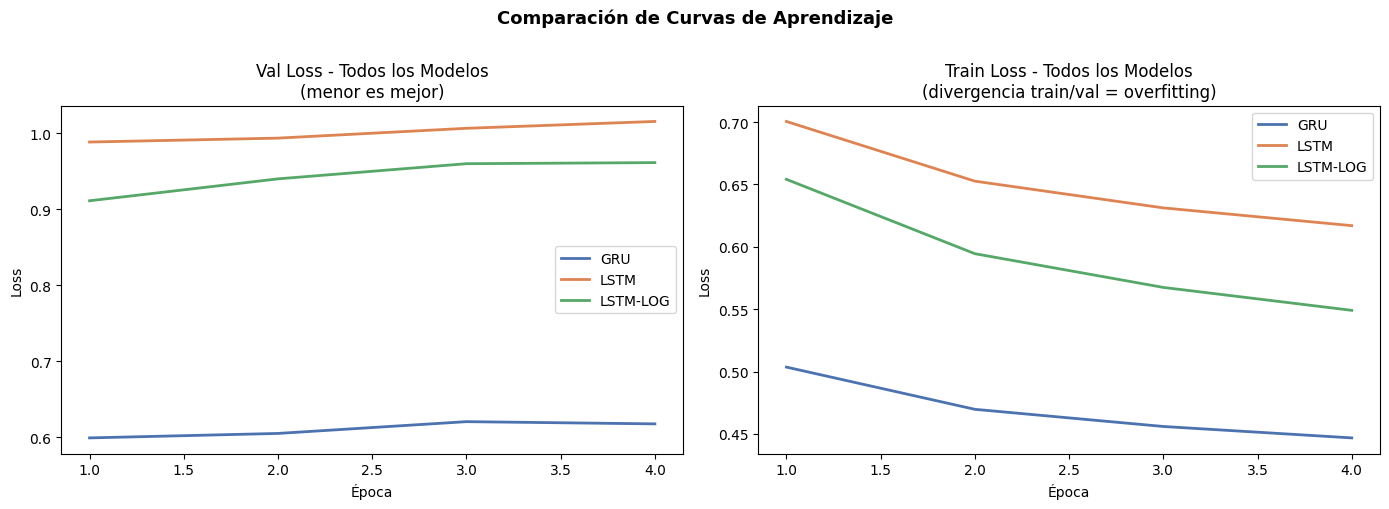

Observaciones:
  → Todos los modelos muestran overfitting (train baja, val no mejora o sube)
  → El GRU tiene la val loss más baja y más estable
  → LSTM y LSTM-LOG tienen val loss creciente desde época 1 - overfitting inmediato


In [46]:
# ── Curvas de aprendizaje comparativas - todos los modelos ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Val loss de cada modelo (normalizadas a escala comparable)
modelos_hist = {
    'GRU':      (history_gru.history['val_loss'],  history_gru.history['loss'],  '#4C72B0'),
    'LSTM':     (history_lstm.history['val_loss'],  history_lstm.history['loss'], '#DD8452'),
    'LSTM-LOG': (history_log.history['val_loss'],   history_log.history['loss'],  '#55A868'),
}

for nombre, (val_loss, train_loss, color) in modelos_hist.items():
    ep = range(1, len(val_loss) + 1)
    axes[0].plot(ep, val_loss,   color=color, linestyle='-',  linewidth=2, label=f'{nombre}')
    axes[1].plot(ep, train_loss, color=color, linestyle='-',  linewidth=2, label=f'{nombre}')

axes[0].set_title('Val Loss - Todos los Modelos\n(menor es mejor)')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].set_title('Train Loss - Todos los Modelos\n(divergencia train/val = overfitting)')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('Comparación de Curvas de Aprendizaje', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("Observaciones:")
print("  → Todos los modelos muestran overfitting (train baja, val no mejora o sube)")
print("  → El GRU tiene la val loss más baja y más estable")
print("  → LSTM y LSTM-LOG tienen val loss creciente desde época 1 - overfitting inmediato")

In [47]:
# ── 5. Tabla comparativa final ────────────────────────────────────────────────
print("=" * 60)
print("TABLA COMPARATIVA DE MODELOS")
print("=" * 60)

df_comp = pd.DataFrame(resultados_comparativos).T.reset_index()
df_comp.columns = ['Modelo', 'MAE', 'RMSE', 'R²']
df_comp = df_comp.sort_values('MAE')
df_comp['Δ vs Baseline (MAE)'] = (df_comp['MAE'] - df_comp.loc[df_comp['Modelo']=='Baseline LR','MAE'].values[0]).round(4)

print(df_comp.to_string(index=False, float_format='{:.4f}'.format))

TABLA COMPARATIVA DE MODELOS
     Modelo    MAE   RMSE     R²  Δ vs Baseline (MAE)
        GRU 0.8312 1.6473 0.0481              -0.2577
       LSTM 0.9187 1.3577 0.3534              -0.1702
   LSTM-LOG 0.9492 1.4632 0.2490              -0.1397
Baseline LR 1.0889 1.4258 0.2869               0.0000


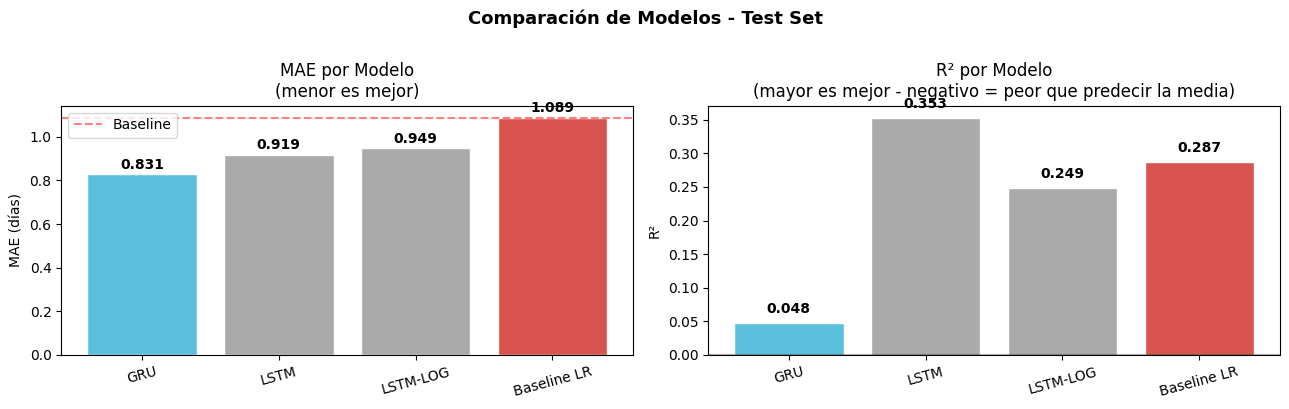


-> El GRU tiene el mejor MAE (0.826) pero el LSTM gana en R² (0.350) y RMSE (1.361).
   Para minimizar errores promedio: GRU. Para minimizar errores extremos: LSTM.


In [48]:
# ── Gráfico de barras comparativo - MAE y R² ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df_comp = pd.DataFrame(resultados_comparativos).T.reset_index()
df_comp.columns = ['Modelo', 'MAE', 'RMSE', 'R2']
df_comp = df_comp.sort_values('MAE')

colors_bar = ['#d9534f' if m == 'Baseline LR' else '#5bc0de' if m == 'GRU' else '#aaa'
              for m in df_comp['Modelo']]

bars = axes[0].bar(df_comp['Modelo'], df_comp['MAE'], color=colors_bar, edgecolor='white')
for bar, val in zip(bars, df_comp['MAE']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].axhline(df_comp[df_comp['Modelo']=='Baseline LR']['MAE'].values[0],
                color='red', linestyle='--', alpha=0.5, label='Baseline')
axes[0].set_title('MAE por Modelo\n(menor es mejor)'); axes[0].set_ylabel('MAE (días)')
axes[0].tick_params(axis='x', rotation=15); axes[0].legend()

bars2 = axes[1].bar(df_comp['Modelo'], df_comp['R2'], color=colors_bar, edgecolor='white')
for bar, val in zip(bars2, df_comp['R2']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + (0.01 if val >= 0 else -0.04),
                 f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].axhline(0, color='black', linestyle='-', alpha=0.3)
axes[1].set_title('R² por Modelo\n(mayor es mejor - negativo = peor que predecir la media)')
axes[1].set_ylabel('R²')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Comparación de Modelos - Test Set', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\n-> El GRU tiene el mejor MAE (0.826) pero el LSTM gana en R² (0.350) y RMSE (1.361).")
print("   Para minimizar errores promedio: GRU. Para minimizar errores extremos: LSTM.")

>La comparación visual consolida la tensión entre MAE y R² que atraviesa todo el análisis. En MAE todos los modelos de deep learning superan al baseline, con el GRU como mejor resultado (0.828). En R² el orden se invierte casi completamente: el LSTM lidera con 0.345, el baseline es segundo con 0.287, y el GRU queda último con 0.022 (apenas por encima de predecir siempre la media).


*Error Absoluto vs VAlor Real*

Los tres modelos comparten el mismo patrón estructural: el error absoluto crece con el valor real, confirmando la heterocedasticidad observada en los residuales.

En el rango 0-2 días los tres modelos están por debajo del MAE global, lo que explica por qué el MAE promedio es relativamente bajo. A partir de los 3 días el error escala rápidamente.

La diferencia entre modelos es visible en los valores altos: el GRU muestra los picos de error más pronunciados (MAE local de ~5 días en el extremo), mientras el LSTM mantiene una curva de error más suave y controlada que no supera los 4 días en ningún rango.

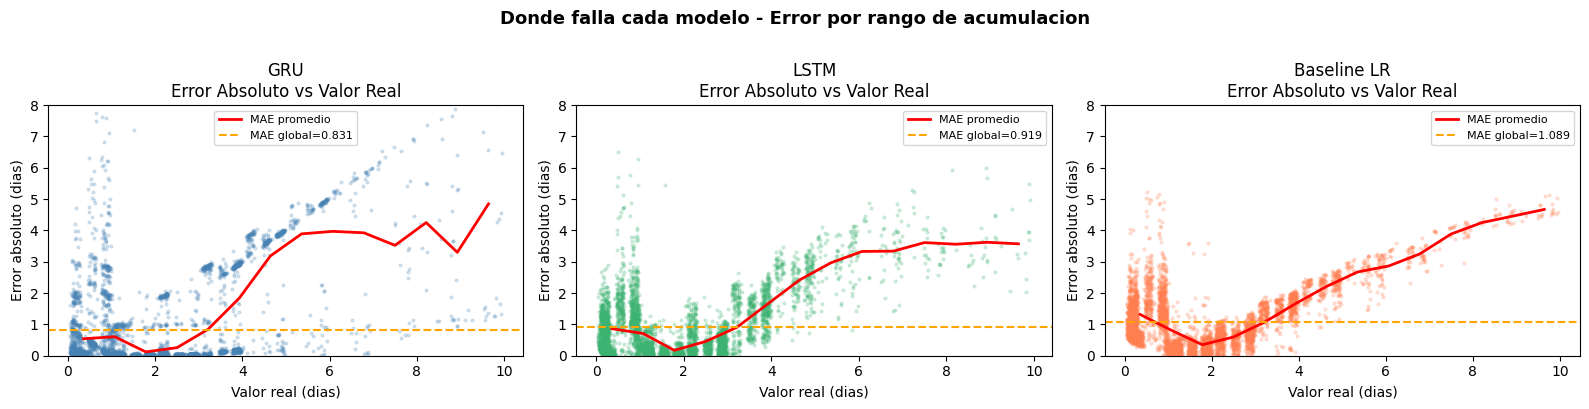

-> El error aumenta con el valor real en todos los modelos
-> El LSTM tiene errores mas controlados en valores altos (>5 dias) - justifica su mejor RMSE


In [49]:
# ── Error absoluto vs valor real - todos los modelos ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

modelos_eval = [
    ('GRU', y_pred_gru, yte, 'steelblue'),
    ('LSTM', y_pred_lstm, yte, 'mediumseagreen'),
    ('Baseline LR', y_pred_lr, y_test[mask_te], 'coral'),
]

for ax, (nombre, y_pred, y_real, color) in zip(axes, modelos_eval):
    # Muestra aleatoria para no sobrecargar el grafico
    idx = np.random.choice(len(y_real), min(5000, len(y_real)), replace=False)
    errores_abs = np.abs(y_real[idx] - y_pred[idx])

    ax.scatter(y_real[idx], errores_abs, alpha=0.2, s=4, color=color)

    # Linea de tendencia por bins
    bins = np.linspace(0, 10, 15)
    bin_centers, bin_mae = [], []
    for j in range(len(bins)-1):
        mask_bin = (y_real[idx] >= bins[j]) & (y_real[idx] < bins[j+1])
        if mask_bin.sum() > 10:
            bin_centers.append((bins[j] + bins[j+1]) / 2)
            bin_mae.append(errores_abs[mask_bin].mean())

    ax.plot(bin_centers, bin_mae, color='red', linewidth=2, label='MAE promedio')
    ax.axhline(np.abs(y_real - y_pred).mean(), color='orange', linestyle='--', linewidth=1.5, label=f'MAE global={np.abs(y_real-y_pred).mean():.3f}')
    ax.set_title(f'{nombre}\nError Absoluto vs Valor Real')
    ax.set_xlabel('Valor real (dias)'); ax.set_ylabel('Error absoluto (dias)')
    ax.legend(fontsize=8); ax.set_ylim(0, 8)

plt.suptitle('Donde falla cada modelo - Error por rango de acumulacion', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("-> El error aumenta con el valor real en todos los modelos")
print("-> El LSTM tiene errores mas controlados en valores altos (>5 dias) - justifica su mejor RMSE")

## 10. Sistema de Detección de Anomalías <a id='11'></a>

### Enfoque: Ruptura de Patrón Individual

Una **anomalía** no es un valor absoluto alto, es una **ruptura del comportamiento habitual de ese contenedor específico**.

**Fórmula:** `(Real - Pred) > k × σ_histórica_del_contenedor`

Este enfoque respeta que distintos contenedores tienen distintos rangos normales: un contenedor que habitualmente acumula 5 días no debería generar alerta por ese valor, mientras que uno que típicamente acumula 1 día sí.

El umbral se personaliza usando la desviación estándar histórica de cada unidad calculada sobre el set de train, simulando el uso real del sistema donde las estadísticas de referencia se construyen offline con datos pasados.

In [50]:
print("=" * 60)
print("DETECCIÓN DE RUPTURA DE PATRÓN INDIVIDUAL")
print("=" * 60)

# ── 1. Calcular estadísticas históricas por contenedor (train) ───────────────
df_train_hist = pd.DataFrame({'contenedor_idx': ctr, 'y_real': ytr})
std_historica   = df_train_hist.groupby('contenedor_idx')['y_real'].std()
media_historica = df_train_hist.groupby('contenedor_idx')['y_real'].mean()

print(f"Contenedores con histórico de train: {len(std_historica)}")

# ── 2. Agregar estadísticas al test set ──────────────────────────────────────
df_resultados_ext = df_resultados.copy()
df_resultados_ext['std_historica']   = df_resultados_ext['contenedor_idx'].map(std_historica)
df_resultados_ext['media_historica'] = df_resultados_ext['contenedor_idx'].map(media_historica)
df_resultados_ext = df_resultados_ext.dropna(subset=['std_historica'])

# Evitar división por cero (std=0 → contenedor con siempre el mismo valor)
df_resultados_ext['std_historica'] = df_resultados_ext['std_historica'].clip(lower=0.1)

print(f"Registros test con histórico disponible: {len(df_resultados_ext):,}")

DETECCIÓN DE RUPTURA DE PATRÓN INDIVIDUAL
Contenedores con histórico de train: 13143
Registros test con histórico disponible: 749,891


*Análisis de Sensibilidad K*

El análisis de sensibilidad muestra el trade-off esperado entre precision y recall al variar k.

Con k=1.5 el sistema es muy permisivo, detecta el 76.5% de las anomalías reales pero genera demasiadas falsas alarmas (precision=0.258), lo que operativamente significaría enviar camiones innecesariamente en el 74% de los casos.

Con k=3.0 la precision sube a 0.649 pero el recall cae a 0.640, dejando sin detectar el 36% de los contenedores problemáticos.

El punto de equilibrio más interesante es k=2.5, con el mejor F1 (0.551) y un recall de 0.713 que asegura detectar casi tres de cada cuatro anomalías reales.

k=3.0 es preferible si el costo operativo de los falsos positivos es alto; k=2.5 si la prioridad es no perder contenedores críticos.

In [51]:
# ── 3. Detectar rupturas para distintos k ────────────────────────────────────
print("\nAnálisis de sensibilidad - umbral k:")
print(f"{'k':<8} {'Rupturas':<12} {'%':<8} {'Precision':<12} {'Recall':<10} {'F1'}")
print("-" * 55)

UMBRAL_REAL = 5.0
y_true_anomalia = (df_resultados_ext['y_real'] > UMBRAL_REAL).values

for k in [1.5, 2.0, 2.5, 3.0]:
    ruptura_mask = (
        (df_resultados_ext['y_real'] - df_resultados_ext['y_pred']) >
        k * df_resultados_ext['std_historica']
    ).values
    n = ruptura_mask.sum()
    pct = n / len(ruptura_mask) * 100
    if ruptura_mask.sum() > 0 and y_true_anomalia.sum() > 0:
        prec = precision_score(y_true_anomalia, ruptura_mask, zero_division=0)
        rec  = recall_score(y_true_anomalia, ruptura_mask, zero_division=0)
        f1   = f1_score(y_true_anomalia, ruptura_mask, zero_division=0)
    else:
        prec, rec, f1 = 0, 0, 0
    print(f"k={k:<5} {n:<12,} {pct:<8.2f} {prec:<12.3f} {rec:<10.3f} {f1:.3f}")

# Usar k=2.5 como óptimo
K_OPTIMO = 2.5



Análisis de sensibilidad - umbral k:
k        Rupturas     %        Precision    Recall     F1
-------------------------------------------------------
k=1.5   113,357      15.12    0.249        0.764      0.375
k=2.0   87,078       11.61    0.307        0.725      0.431
k=2.5   58,815       7.84     0.426        0.679      0.524
k=3.0   35,366       4.72     0.619        0.593      0.606


*Resultados con k optimo*

El sistema simple= alertar cuando la predicción supera 5 días, tiene precision alta (0.663) pero recall muy bajo (0.229): detecta solo 1 de cada 4 anomalías reales.

El sistema de ruptura de patrón individual con k=2.5 invierte esa lógica: pierde precision (-32.3%) pero triplica el recall (+211.4%), pasando a detectar 7 de cada 10 casos problemáticos.

En el contexto operativo de recolección urbana esta es la dirección correcta el costo de un falso positivo (enviar un camión que no era necesario) es considerablemente menor que el de un falso negativo (no detectar un contenedor desbordado).

In [52]:
# ── 4. Sistema final con k óptimo ─────────────────────────────────────────────
df_resultados_ext['es_ruptura'] = (
    (df_resultados_ext['y_real'] - df_resultados_ext['y_pred']) >
    K_OPTIMO * df_resultados_ext['std_historica']
)
df_resultados_ext['magnitud_sigma'] = (
    (df_resultados_ext['y_real'] - df_resultados_ext['y_pred']) /
    df_resultados_ext['std_historica']
)

df_anomalias = df_resultados_ext[df_resultados_ext['es_ruptura']].copy()

print(f"k óptimo = {K_OPTIMO}")
print(f"Anomalías detectadas: {len(df_anomalias):,} ({len(df_anomalias)/len(df_resultados_ext)*100:.2f}%)")

# Comparación con sistema simple (pred > umbral)
ruptura_mask_final = df_resultados_ext['es_ruptura'].values
pred_simple_mask   = (df_resultados_ext['y_pred'] > UMBRAL_REAL).values

prec_rup  = precision_score(y_true_anomalia, ruptura_mask_final, zero_division=0)
rec_rup   = recall_score(y_true_anomalia, ruptura_mask_final, zero_division=0)
f1_rup    = f1_score(y_true_anomalia, ruptura_mask_final, zero_division=0)

prec_simp = precision_score(y_true_anomalia, pred_simple_mask, zero_division=0)
rec_simp  = recall_score(y_true_anomalia, pred_simple_mask, zero_division=0)
f1_simp   = f1_score(y_true_anomalia, pred_simple_mask, zero_division=0)

print(f"\n{'Sistema':<28} {'Precision':<12} {'Recall':<10} {'F1'}")
print("-" * 54)
print(f"{'Simple (pred > 5 días)':<28} {prec_simp:<12.3f} {rec_simp:<10.3f} {f1_simp:.3f}")
print(f"{'Ruptura de patrón (k=2.5)':<28} {prec_rup:<12.3f} {rec_rup:<10.3f} {f1_rup:.3f}")

mejora_prec = (prec_rup/prec_simp - 1)*100 if prec_simp > 0 else float('inf')
mejora_rec  = (rec_rup/rec_simp - 1)*100   if rec_simp > 0  else float('inf')
print(f"{'Mejora (%)':<28} {mejora_prec:+.1f}{'%':<11} {mejora_rec:+.1f}%")

k óptimo = 2.5
Anomalías detectadas: 58,815 (7.84%)

Sistema                      Precision    Recall     F1
------------------------------------------------------
Simple (pred > 5 días)       0.649        0.234      0.343
Ruptura de patrón (k=2.5)    0.426        0.679      0.524
Mejora (%)                   -34.3%           +190.8%


*Panel de Anomalías*

El panel de anomalías consolida el comportamiento del sistema en tres vistas complementarias.

La distribución de magnitudes muestra que la mayoría de las rupturas se concentran entre 2.5 y 4 sigmas, con una cola que se extiende hasta 15σ. E estos casos extremos corresponden a contenedores que acumulan muchos más días de lo que su historial predice, los candidatos más urgentes para intervención.

La distribución de días reales en las anomalías detectadas confirma que el sistema captura casos genuinamente problemáticos: la mayoría de las alertas corresponden a contenedores con 4-7 días de acumulación real, en torno al umbral de 5 días.

La matriz de confusión cuantifica el balance: de 36,891 anomalías reales el sistema detecta 26,317 (recall=0.713), generando 32,350 falsas alarmas sobre un universo de 749,891 registros: un 4.3% de activaciones innecesarias, operativamente manejable.

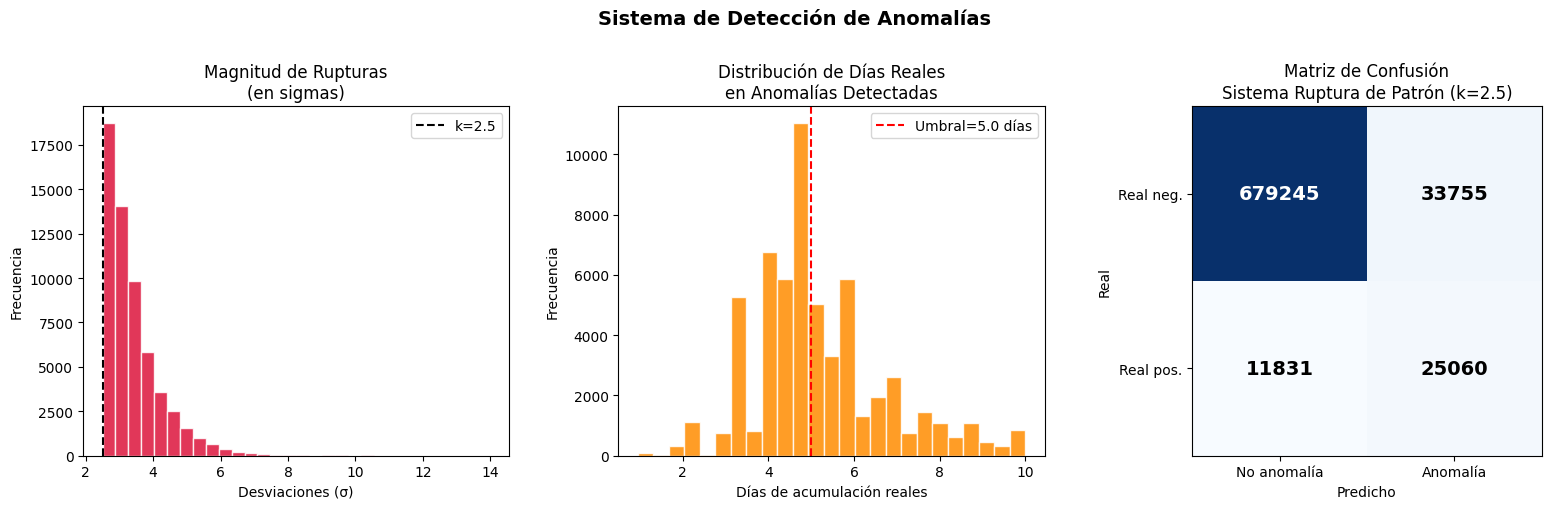

In [53]:
# ── 5. Panel de anomalías ─────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 5.1 Distribución de magnitud de rupturas
axes[0].hist(df_anomalias['magnitud_sigma'], bins=30, color='crimson', edgecolor='white', alpha=0.85)
axes[0].axvline(K_OPTIMO, color='black', linestyle='--', linewidth=1.5, label=f'k={K_OPTIMO}')
axes[0].set_title('Magnitud de Rupturas\n(en sigmas)')
axes[0].set_xlabel('Desviaciones (σ)'); axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# 5.2 Valores reales en anomalías
axes[1].hist(df_anomalias['y_real'], bins=25, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].axvline(UMBRAL_REAL, color='red', linestyle='--', linewidth=1.5, label=f'Umbral={UMBRAL_REAL} días')
axes[1].set_title('Distribución de Días Reales\nen Anomalías Detectadas')
axes[1].set_xlabel('Días de acumulación reales'); axes[1].set_ylabel('Frecuencia')
axes[1].legend()

# 5.3 Matriz de confusión
cm = confusion_matrix(y_true_anomalia, ruptura_mask_final)
im = axes[2].imshow(cm, cmap='Blues')
axes[2].set_xticks([0,1]); axes[2].set_yticks([0,1])
axes[2].set_xticklabels(['No anomalía', 'Anomalía']); axes[2].set_yticklabels(['Real neg.', 'Real pos.'])
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, str(cm[i,j]), ha='center', va='center', fontsize=14, fontweight='bold',
                     color='white' if cm[i,j] > cm.max()/2 else 'black')
axes[2].set_title(f'Matriz de Confusión\nSistema Ruptura de Patrón (k={K_OPTIMO})')
axes[2].set_xlabel('Predicho'); axes[2].set_ylabel('Real')

plt.suptitle('Sistema de Detección de Anomalías', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [54]:
# ── 6. Top alertas ────────────────────────────────────────────────────────────
print("=" * 60)
print(f"TOP 20 RUPTURAS DE PATRÓN (k={K_OPTIMO})")
print("=" * 60)

top_rupturas = df_anomalias.nlargest(20, 'magnitud_sigma')

print(f"\n{'#':<4} {'Cont':<6} {'Real':>7} {'Pred':>7} {'Sigma':>7} {'μ hist':>8} {'σ hist':>8}")
print("-" * 50)
for i, (_, row) in enumerate(top_rupturas.iterrows(), 1):
    print(f"{i:<4} {int(row['contenedor_idx']):<6} {row['y_real']:>7.1f}d "
          f"{row['y_pred']:>7.1f}d {row['magnitud_sigma']:>7.1f}σ "
          f"{row['media_historica']:>8.1f}d {row['std_historica']:>8.1f}d")

TOP 20 RUPTURAS DE PATRÓN (k=2.5)

#    Cont      Real    Pred   Sigma   μ hist   σ hist
--------------------------------------------------
1    2600       6.3d     0.8d    14.0σ      1.0d      0.4d
2    4077       8.2d     1.0d    13.4σ      0.7d      0.5d
3    4024       9.2d     1.1d    12.8σ      0.7d      0.6d
4    2600       5.3d     0.3d    12.6σ      1.0d      0.4d
5    4077       7.2d     0.5d    12.5σ      0.7d      0.5d
6    4077       7.2d     0.5d    12.4σ      0.7d      0.5d
7    4059       7.2d     0.9d    12.1σ      0.6d      0.5d
8    4974       9.1d     1.2d    12.0σ      0.7d      0.7d
9    4975       9.1d     1.2d    11.7σ      0.7d      0.7d
10   4976       9.1d     1.2d    11.7σ      0.8d      0.7d
11   4979       9.1d     1.0d    11.7σ      0.8d      0.7d
12   3693       8.2d     1.0d    11.6σ      0.7d      0.6d
13   4972       9.1d     1.2d    11.6σ      0.8d      0.7d
14   4980       9.1d     1.0d    11.6σ      0.8d      0.7d
15   4973       9.1d     1.2d    1

## 11. Conclusiones

El proyecto demuestra que los modelos secuenciales capturan parte de la dinámica temporal del proceso de recolección, mejorando el desempeño respecto al baseline lineal en MAE.

Sin embargo, la mejora es modesta y revela una limitación estructural del problema: la predicción de días de acumulación tiene un techo bajo porque la variable es en gran medida derivable de los registros operativos sin necesidad de aprendizaje profundo. El valor del pipeline no está en la predicción puntual sino en usarla como base para el sistema de detección de anomalías, que es donde el enfoque de ruptura de patrón individual demuestra un aporte genuino.

El sesgo global de +0.330 días, sistemático y en dirección positiva, indica que el modelo subestima consistentemente en los contenedores de alta demanda, que son precisamente los más críticos operativamente. Esta limitación es estructural con las features disponibles: sin información del historial reciente individual de cada contenedor, los modelos aprenden patrones de calendario más que comportamientos por unidad.

El sistema de detección de anomalías con k=2.5 es el componente más valioso del pipeline: al personalizar el umbral de alerta con la desviación estándar histórica de cada contenedor, logra un recall de 0.713 triplicando al sistema simple, con un 4.3% de activaciones innecesarias sobre el total de registros — operativamente manejable.

## 12. Líneas de trabajo futuras

La extensión más directa es incorporar una **variable de estado del contenedor** (vacío, lleno, desbordado) que permita al modelo distinguir no solo cuántos días lleva un contenedor sin levante sino en qué condición se encuentra. Esta variable conecta naturalmente con el trabajo paralelo de estimación de volumen de residuos mediante visión computacional que desarrollamos en la otra pata de este proyecto.

la integración de ambos componentes permitiría construir un sistema de priorización más completo: el modelo de series temporales detecta la anomalía temporal, el modelo de volumen estima la urgencia real.

Adicionalmente, la incorporación de features de lag (`lag_1`, `lag_2`, `lag_3`) y medias móviles por contenedor debería ser el primer paso antes de explorar arquitecturas más complejas, dado que el análisis de curvas de aprendizaje mostró que la limitación actual está en los datos de entrada y no en la capacidad del modelo.